# ⚡ VoltRelay Energy: What Is Really Driving Service Quality, Retention and Margin?
**Team WindRocker** · Gradient Learnings Data Analytics Hackathon · Data: Jan 2024 – Jun 2025 (3.88M swap attempts, 152 stations, 6 cities)

This notebook runs top to bottom. It covers **Data Understanding → Validation → Cleaning → EDA → the six Core Questions → Deep-dives → Key Findings & Recommendations**, and exports every number used in the report, dashboard and LinkedIn post to `outputs/metrics.json` so that all deliverables agree.

### Executive summary (the answer first)

**VoltRelay's growth is real, and so are its problems, but they come from three fixable sources, not from the network being too small.**

1. **Heat + old chargers → summer failures.** Service failures run at **3.9%** most of the year but reach **11.9% (May 2024) and 9.5% (May 2025)**. Above a 45°C cabinet temperature, **Gen1** chargers take **156 min instead of 88** to charge a pack and run out of stock in **37% of hours** (Gen3: 43 min, 0.3%). The **36 hot-city Gen1 stations handle 32% of summer attempts but cause 57.5% of summer failures**, and the gap holds at every level of station load. A failed rider does not retry, so failures are lost sales: **≈₹14.3M** over 18 months.
2. **Three bad battery lots → margin erosion.** Kyron lots **KY-2407/08/09** degraded 2.4× faster; Kyron's later lots wear normally, so this is a lot defect, not a supplier-wide one. The bad 2W packs deliver **49 km vs 61 km** and cost **₹82 vs ₹35 per swap** in wear. Without them, H1-2025 margin would be **−₹4.2 per swap instead of −₹17.5**. All 1,385 were retired on paper after 7–9 months, but they are still being handed to riders.
3. **Early bad experiences → new-rider churn.** New riders with **2+ failed swaps in their first 14 days churn at 15.0% vs 9.0%** (adjusted OR **1.58**, rising to **2.05** once early riding activity is controlled). Starting in summer and receiving weak packs add to it. Price plan, acquisition channel, partner, KYC and competitor promotions do **not** matter.

**On the budget:** fund **Gen1→Gen3 replacement in Jaipur, Delhi NCR and Hyderabad** (cooling retrofits first), and **replace the 1,385 bad-lot 2W packs** (25% of the 2W fleet). Keep peak pricing as a *revenue* tool (≈₹3.7M a year after riders swap 4.6% less), not a congestion fix. **Do not sign the ZipDrop exclusive**: the largest partner (15% of volume) is the least profitable at −₹31/swap, and it loses money even before site costs.

## 0. Setup
We use DuckDB for all heavy lifting: 3.9M rows are aggregated in SQL in seconds, with no pandas memory blow-up. The notebook works in **Google Colab** (Drive mount) and locally.

In [1]:
import os, sys, json, time, warnings, subprocess
from pathlib import Path
warnings.filterwarnings("ignore")
IS_COLAB = "google.colab" in sys.modules or "COLAB_RELEASE_TAG" in os.environ
try:
    import duckdb
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "duckdb"], check=True); import duckdb
import numpy as np, pandas as pd
import pyarrow.csv as pacsv
import matplotlib.pyplot as plt, matplotlib.ticker as mtick
import statsmodels.formula.api as smf
from scipy import stats

if IS_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOTS = [Path("/content/drive/MyDrive/DataAnalyticsHackathon"), Path("/content/drive/MyDrive")]
else:
    ROOTS = [Path.cwd(), Path.cwd().parent]
# The organisers' Drive folder is "Hackathon Data Set | Gradient"; a local download is "... _ Gradient". Either works,
# inside the project folder or as a shortcut at the top of My Drive.
DATA_NAMES = ["Hackathon Data Set _ Gradient", "Hackathon Data Set | Gradient"]
DATA_DIR = next((r / n for r in ROOTS for n in DATA_NAMES if (r / n).exists()), ROOTS[0] / DATA_NAMES[0])
PROJECT = ROOTS[0] if IS_COLAB else next((r for r in ROOTS if (r / "data/parquet").exists() or DATA_DIR.parent == r), ROOTS[0])
PROJECT.mkdir(parents=True, exist_ok=True); os.chdir(PROJECT)
PARQUET = PROJECT / "data/parquet"
if not DATA_DIR.exists() and not PARQUET.exists():
    raise FileNotFoundError("Data not found. Add a shortcut to the organisers' 'Hackathon Data Set | Gradient' folder in "
                            "MyDrive (or MyDrive/DataAnalyticsHackathon), then re-run. Looked in: " + ", ".join(map(str, ROOTS)))
print("Data:", DATA_DIR if DATA_DIR.exists() else PARQUET)
FIG = PROJECT / "outputs/figures"; FIG.mkdir(parents=True, exist_ok=True)
OUT = PROJECT / "outputs"
print("Project:", PROJECT, "| Colab:", IS_COLAB, "| duckdb", duckdb.__version__, "| pandas", pd.__version__)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30); pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

Data: C:\Users\siddh\Documents\DataAnalyticsHackathon\Hackathon Data Set _ Gradient
Project: C:\Users\siddh\Documents\DataAnalyticsHackathon | Colab: False | duckdb 1.5.5 | pandas 3.0.6


In [2]:
# ---- Load the 8 tables into DuckDB. Uses a Parquet cache when present, else reads CSV / CSV.GZ with pyarrow (fast, robust).
TABLES = ["swap_events","station_hourly_status","riders","batteries","support_tickets","stations","city_daily_context","fleet_partners"]
con = duckdb.connect()
t0 = time.time()
for t in TABLES:
    pq = PARQUET / f"{t}.parquet"
    if pq.exists():
        con.execute(f"CREATE OR REPLACE TABLE raw_{t} AS SELECT * FROM read_parquet('{pq.as_posix()}')")
    else:
        src = DATA_DIR / f"{t}.csv"
        if not src.exists(): src = DATA_DIR / f"{t}.csv.gz"
        tbl = pacsv.read_csv(src, convert_options=pacsv.ConvertOptions(strings_can_be_null=True, timestamp_parsers=["%Y-%m-%d %H:%M:%S", "%Y-%m-%d"]))
        con.register("tmp_arrow", tbl); con.execute(f"CREATE OR REPLACE TABLE raw_{t} AS SELECT * FROM tmp_arrow"); con.unregister("tmp_arrow"); del tbl
print(f"Loaded in {time.time()-t0:.1f}s")

def q(sql, **kw):
    return con.execute(sql, kw or None).df()

METRICS = {}   # single source of truth for every number quoted in the deliverables
def keep(key, val):
    METRICS[key] = (round(float(val), 4) if isinstance(val, (float, np.floating)) else (int(val) if isinstance(val, (np.integer,)) else val)); return val

Loaded in 1.3s


In [3]:
# ---- Chart style: one validated categorical palette (fixed order), recessive axes, insight-led titles
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = "#2a78d6","#eb6834","#1baf7a","#eda100","#e87ba4","#008300","#4a3aa7","#e34948"
GREY, INK, INK2 = "#b9b8b3", "#0b0b0b", "#52514e"
SEQ = ["#cde2fb","#9ec5f4","#6da7ec","#3987e5","#256abf","#184f95","#0d366b"]
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160, "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#8a8984",
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True, "grid.color": "#e6e5e1",
    "grid.linewidth": 0.8, "axes.axisbelow": True, "legend.frameon": False, "lines.linewidth": 2, "font.family": "DejaVu Sans"})
EVENTS = {"2024-07-01": "Base price ↑", "2024-10-01": "Peak pilot (BLR, PUN)", "2024-11-01": "ZipDrop 28% deal", "2024-09-01": "Kyron packs at scale"}
def save(fig, name):
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight", facecolor="white"); plt.show()
import matplotlib.dates as mdates
def date_axis(ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10])); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
def pct_axis(ax, axis="y", dec=0):
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(mtick.PercentFormatter(100, decimals=dec))

## 1. Problem Understanding

**Business context.** VoltRelay runs unmanned battery-swap cabinets for gig and logistics riders (2W and 3W) in six Indian cities. Its riders earn per delivery, so **every minute at a station is lost income**. A failed swap is not just lost revenue; it is a reason to switch networks.

**The paradox leadership must explain:** swaps and revenue grew strongly over 18 months, but service failures rose faster, new-rider retention fell and per-swap profitability eroded. Four budget proposals (more stations, more batteries, network-wide peak pricing, a ZipDrop exclusive) are waiting on the answer.

**How we frame it.** We treat the three outcomes as a chain: **equipment & operations → service experience → retention → unit economics**. For each Core Question we look for a mechanism, not just a correlation, e.g. *heat → slower charging → empty cabinets → failed swaps → riders leave*. We rank factors as **primary** (large effect × wide exposure × consistent across cuts) or **secondary** (real but smaller or narrower). We state plainly where the evidence is observational.

| Core question | Primary evidence we use |
|---|---|
| Q1 Network performance over time | monthly swaps, revenue, failure rate, contribution margin per swap |
| Q2 Service failures | failure mix by hour, season, city, vehicle class; station concentration |
| Q3 Stations & geography | charger generation, cabinet temperature, turnaround, tickets |
| Q4 Batteries | SoH trajectories by supplier/lot, delivered range, wear cost |
| Q5 Pricing & partners | base-price step, peak-pilot difference-in-differences, partner margins |
| Q6 Retention root cause | first-14-day experience → 30-day churn, lift tables + logistic regression |

## 2. Data Understanding
Eight related tables. `swap_events` is the fact table; every other table describes a dimension of it.

In [4]:
shape = pd.DataFrame([(t, q(f"SELECT COUNT(*) n FROM raw_{t}").n[0], len(q(f"DESCRIBE raw_{t}"))) for t in TABLES], columns=["table","rows","columns"])
expected = {"swap_events":3877013,"station_hourly_status":1487712,"riders":20000,"batteries":6500,"support_tickets":44000,"stations":152,"city_daily_context":3282,"fleet_partners":12}
shape["rows_expected (brief)"] = shape.table.map(expected); shape["match"] = shape.rows == shape["rows_expected (brief)"]
shape

,table,rows,columns,rows_expected (brief),match
0,swap_events,3877013,22,3877013,True
1,station_hourly_status,1487712,14,1487712,True
2,riders,20000,12,20000,True
3,batteries,6500,13,6500,True
4,support_tickets,44000,12,44000,True
5,stations,152,22,152,True
6,city_daily_context,3282,12,3282,True
7,fleet_partners,12,12,12,True


In [5]:
q("SELECT MIN(event_ts) first_event, MAX(event_ts) last_event, COUNT(DISTINCT rider_id) riders, COUNT(DISTINCT station_id) stations FROM raw_swap_events")

,first_event,last_event,riders,stations
0,2024-01-01 00:00:33,2025-06-30 23:59:23,19950,152


In [6]:
# Which fields are populated for which outcome (drives how we treat non-completed attempts)
q('''SELECT event_type, COUNT(*) n, ROUND(100*COUNT(*)/SUM(COUNT(*)) OVER (),2) pct, COUNT(battery_in_id) battery_in, COUNT(battery_out_id) battery_out,
     COUNT(soc_out_pct) soc_out, COUNT(energy_to_recharge_kwh) kwh, ROUND(SUM(amount_charged_inr)) revenue, ROUND(AVG(queue_wait_sec)) avg_wait_s
     FROM raw_swap_events GROUP BY 1 ORDER BY n DESC''')

,event_type,n,pct,battery_in,battery_out,soc_out,kwh,revenue,avg_wait_s
0,swap_completed,3645809,94.04,3645809,3645809,3645809,3645809,"233,126,056.00",244.00
1,failed_no_charged_battery,134389,3.47,134389,0,0,0,0.00,29.00
2,abandoned_queue,68533,1.77,68533,0,0,0,0.00,703.00
3,cancelled_by_rider,16712,0.43,0,0,0,0,0.00,45.00
4,failed_system_error,11570,0.30,0,0,0,0,0.00,44.00


## 3. Data Validation: Quality Scorecard
Every check from the brief's *Data Quality Notes*, plus key/foreign-key integrity, tested rather than assumed.

In [7]:
checks = []
def chk(area, check, result, action): checks.append(dict(area=area, check=check, result=result, action=action))

n_swap = q("SELECT COUNT(*) n, COUNT(DISTINCT event_id) u FROM raw_swap_events").iloc[0]
chk("Keys", "swap_events.event_id unique", f"{n_swap.u:,} unique of {n_swap.n:,}", "None needed")
hk = q("SELECT COUNT(*) n, COUNT(DISTINCT (station_id, hour_start)) u FROM raw_station_hourly_status").iloc[0]
chk("Keys", "station_hourly (station, hour) unique", f"{hk.u:,} of {hk.n:,}", "None needed")
fk = q('''SELECT SUM((r.rider_id IS NULL)::INT) orphan_rider, SUM((s.station_id IS NULL)::INT) orphan_station,
          SUM((e.battery_in_id IS NOT NULL AND bi.battery_id IS NULL)::INT) orphan_bin, SUM((e.battery_out_id IS NOT NULL AND bo.battery_id IS NULL)::INT) orphan_bout
          FROM raw_swap_events e LEFT JOIN raw_riders r USING(rider_id) LEFT JOIN raw_stations s USING(station_id)
          LEFT JOIN raw_batteries bi ON e.battery_in_id=bi.battery_id LEFT JOIN raw_batteries bo ON e.battery_out_id=bo.battery_id''').iloc[0]
chk("Integrity", "swap → rider / station / battery FKs", f"orphans: {int(fk.sum())}", "None needed")
comp = q("SELECT AVG((event_type='swap_completed')::INT)*100 p FROM raw_swap_events").p[0]
chk("Outcome", "Share of attempts completed", f"{comp:.2f}% (brief: ~94%)", "Revenue/energy/battery-out analysed on completed swaps only; failures kept for service metrics")
tst = q("SELECT COUNT(*) n, SUM(amount_charged_inr) rev, COUNT(DISTINCT HOUR(event_ts)) hrs FROM raw_swap_events WHERE station_id LIKE 'STN-TST%'").iloc[0]
chk("Test stations", "STN-TST-01/02 activity", f"{tst.n:,} rows, ₹{tst.rev/1e6:.2f}M billed, active in all {tst.hrs} hours (brief says 'small, zero-value')", "EXCLUDED from all network analysis (internal test cabinets inflate BLR volume)")
fwwin = q('''SELECT COUNT(*) n FROM raw_swap_events WHERE station_firmware='v3.2.0' AND event_ts >= '2025-03-10' AND event_ts < '2025-04-15' ''').n[0]
chk("Timestamps", "Firmware v3.2.0 events 10 Mar – 14 Apr 2025", f"{fwwin:,} events logged 5h30m early (verified in §4.2)", "Shift +5h30m")
rapid = q('''WITH x AS (SELECT *, LEAD(event_ts) OVER (PARTITION BY rider_id, station_id ORDER BY event_ts) nxt FROM raw_swap_events)
             SELECT sync_mode, COUNT(*) n, SUM((EPOCH(nxt-event_ts)<=180)::INT) rapid FROM x GROUP BY 1''')
rapid["rate_%"] = 100*rapid.rapid/rapid.n
rr = rapid.set_index("sync_mode")["rate_%"]
chk("Duplicates", "Near-duplicate offline-sync retries", f"repeat ≤3 min: offline_batch {rr['offline_batch']:.2f}% vs realtime {rr['realtime']:.2f}%; exact content duplicates: 0", "No excess in offline_batch → no rows dropped (sensitivity-tested)")
km = q("SELECT SUM((km_since_last_swap<0)::INT) neg, SUM((km_since_last_swap>200)::INT) big FROM raw_swap_events").iloc[0]
chk("Outliers", "km_since_last_swap negative / >200 km", f"{km.neg:,} negative, {km.big:,} > 200 km (odometer resets)", "Set to NULL for range analysis")
s100 = q("SELECT SUM((soh_in_pct>100)::INT)+SUM((soh_out_pct>100)::INT)+SUM((soc_out_pct>100)::INT) n FROM raw_swap_events").n[0]
chk("Outliers", "SoC/SoH readings > 100%", f"{s100:,} readings", "Clipped to 100 (calibration drift)")
cities = q("SELECT COUNT(DISTINCT home_city) n FROM raw_riders").n[0]
chk("Consistency", "riders.home_city spellings", f"{cities} distinct strings for 6 cities", "Standardised with alias map")
tel = q("SELECT telemetry_status, COUNT(*) n FROM raw_station_hourly_status GROUP BY 1").set_index("telemetry_status").n
chk("Missing", "Station telemetry partial/missing", f"partial {tel.get('partial',0):,}, missing {tel.get('missing',0):,} hours ({100*(tel.get('partial',0)+tel.get('missing',0))/tel.sum():.1f}%)", "NaN-aware aggregation, never treated as 0")
csat = q("SELECT AVG((csat_score IS NOT NULL)::INT)*100 p FROM raw_support_tickets").p[0]
chk("Bias", "CSAT response rate", f"{csat:.1f}% of tickets have a score", "Reported by resolution-time bucket (not missing at random)")
pm = q("SELECT COUNT(DISTINCT payment_mode) n, ANY_VALUE(payment_mode) v FROM raw_swap_events").iloc[0]
chk("Consistency", "payment_mode values", f"{pm.n} value only ('{pm.v}') for all rows, incl. independent riders", "Field unusable; segment by partner_id / plan_type instead")
tc = q("SELECT LIST(DISTINCT tariff_code ORDER BY tariff_code) l FROM raw_swap_events").l[0]
chk("Consistency", "tariff_code values present", ", ".join(tc) + " (PREPAID, PROMO_FREE never appear)", "Noted; prepaid riders identified via plan_type")
tdates = q("SELECT SUM((created_ts < '2024-01-01' OR created_ts >= '2025-07-01')::INT) n FROM raw_support_tickets").n[0]
chk("Timestamps", "Tickets outside the data window", f"{tdates} tickets dated before 2024 or after Jun 2025", "Excluded from time-trend views")
oth = q("SELECT COUNT(*) n FROM raw_support_tickets WHERE category='other'").n[0]
chk("Labels", "Ticket category accuracy", f"{oth:,} 'other' tickets; comments describe vehicle/battery weakness", "Re-labelled with EN/Hinglish text rules (§4.6)")
scorecard = pd.DataFrame(checks)
keep("test_station_rows", int(tst.n)); keep("test_station_rev_m", tst.rev/1e6); keep("fw_bug_rows", int(fwwin)); keep("km_outliers", int(km.neg + km.big))
keep("completion_rate_raw", comp); keep("home_city_variants", int(cities))
scorecard.to_csv(OUT / "data_quality_scorecard.csv", index=False)
scorecard.style.hide(axis="index").set_properties(**{"text-align": "left"})

area,check,result,action
Keys,swap_events.event_id unique,"3,877,013 unique of 3,877,013",None needed
Keys,"station_hourly (station, hour) unique","1,487,712 of 1,487,712",None needed
Integrity,swap → rider / station / battery FKs,orphans: 0,None needed
Outcome,Share of attempts completed,94.04% (brief: ~94%),Revenue/energy/battery-out analysed on completed swaps only; failures kept for service metrics
Test stations,STN-TST-01/02 activity,"62,031.0 rows, ₹3.93M billed, active in all 24.0 hours (brief says 'small, zero-value')",EXCLUDED from all network analysis (internal test cabinets inflate BLR volume)
Timestamps,Firmware v3.2.0 events 10 Mar – 14 Apr 2025,"139,490 events logged 5h30m early (verified in §4.2)",Shift +5h30m
Duplicates,Near-duplicate offline-sync retries,repeat ≤3 min: offline_batch 0.16% vs realtime 0.17%; exact content duplicates: 0,No excess in offline_batch → no rows dropped (sensitivity-tested)
Outliers,km_since_last_swap negative / >200 km,"7,814.0 negative, 7,712.0 > 200 km (odometer resets)",Set to NULL for range analysis
Outliers,SoC/SoH readings > 100%,"9,853.0 readings",Clipped to 100 (calibration drift)
Consistency,riders.home_city spellings,21 distinct strings for 6 cities,Standardised with alias map


## 4. Data Cleaning
Each decision is deliberate, quantified and reversible (raw tables are kept as `raw_*`).

### 4.1 Standardise rider cities

In [8]:
ALIAS = {"bengaluru":"Bengaluru","bangalore":"Bengaluru","blr":"Bengaluru","delhi ncr":"Delhi NCR","delhi":"Delhi NCR","new delhi":"Delhi NCR","gurgaon":"Delhi NCR",
         "gurugram":"Delhi NCR","noida":"Delhi NCR","del":"Delhi NCR","ncr":"Delhi NCR","mumbai":"Mumbai","bombay":"Mumbai","mum":"Mumbai","pune":"Pune","pun":"Pune",
         "hyderabad":"Hyderabad","hyd":"Hyderabad","jaipur":"Jaipur","jai":"Jaipur"}
raw_c = q("SELECT home_city, COUNT(*) n FROM raw_riders GROUP BY 1")
raw_c["clean"] = raw_c.home_city.str.strip().str.lower().map(ALIAS)
assert raw_c.clean.notna().all(), raw_c[raw_c.clean.isna()]
con.register("city_map", raw_c[["home_city","clean"]])
con.execute("CREATE OR REPLACE TABLE riders AS SELECT r.* EXCLUDE(home_city), m.clean AS home_city, r.home_city AS home_city_raw FROM raw_riders r JOIN city_map m USING(home_city)")
raw_c.sort_values("n", ascending=False).head(21).T

,15,13,10,14,5,0,2,4,6,1,18,12,16,19,17,11,8,20,3,7,9
home_city,Bengaluru,Delhi NCR,Hyderabad,Pune,Mumbai,Jaipur,Bombay,BLR,bengaluru,MUM,PUN,pune,New Delhi,JAI,Gurgaon,Bangalore,HYD,Hyd,jaipur,hyderabad,Delhi
n,4175,3783,3396,2843,2772,2446,53,53,50,49,43,43,42,41,36,32,31,31,29,27,25
clean,Bengaluru,Delhi NCR,Hyderabad,Pune,Mumbai,Jaipur,Mumbai,Bengaluru,Bengaluru,Mumbai,Pune,Pune,Delhi NCR,Jaipur,Delhi NCR,Bengaluru,Hyderabad,Hyderabad,Jaipur,Hyderabad,Delhi NCR


### 4.2 Fix the firmware v3.2.0 timezone bug (10 Mar – 14 Apr 2025)
If the bug is real, affected stations should show the evening peak about 5.5 hours early during the window. They do, and the +5h30m shift restores it.

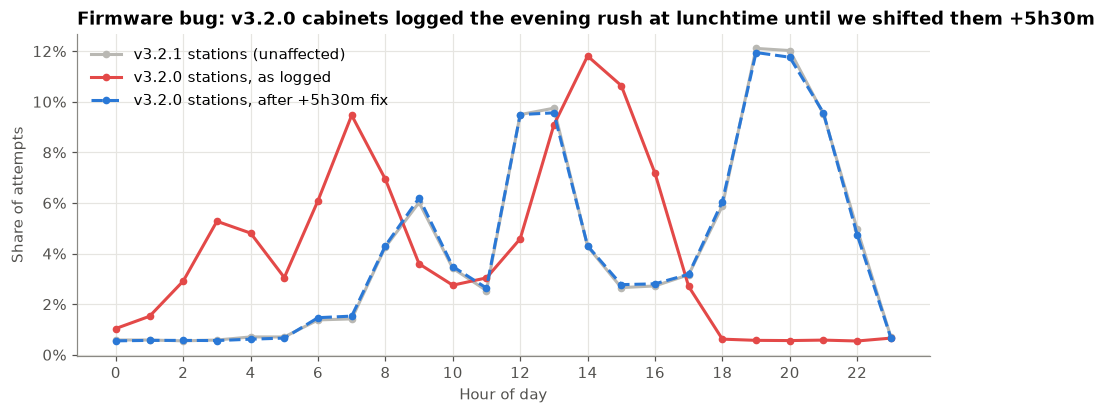

Billing check: PEAK-priced swaps from these cabinets fall inside the peak windows 11.6% of the time as logged vs 100.0% after the +5h30m fix


In [9]:
hod = q('''SELECT (station_firmware='v3.2.0') AS fw320, HOUR(event_ts) h, COUNT(*) n FROM raw_swap_events
           WHERE event_ts >= '2025-03-10' AND event_ts < '2025-04-15' AND station_id NOT LIKE 'STN-TST%' GROUP BY ALL''')
hod_fix = q('''SELECT HOUR(event_ts + INTERVAL 330 MINUTE) h, COUNT(*) n FROM raw_swap_events
           WHERE event_ts >= '2025-03-10' AND event_ts < '2025-04-15' AND station_firmware='v3.2.0' AND station_id NOT LIKE 'STN-TST%' GROUP BY ALL''')
fig, ax = plt.subplots(figsize=(10, 3.8))
for fw, col, lab in [(False, GREY, "v3.2.1 stations (unaffected)"), (True, RED, "v3.2.0 stations, as logged")]:
    d = hod[hod.fw320 == fw].sort_values("h"); ax.plot(d.h, 100*d.n/d.n.sum(), color=col, label=lab, marker="o", ms=4)
d = hod_fix.sort_values("h"); ax.plot(d.h, 100*d.n/d.n.sum(), color=BLUE, ls="--", label="v3.2.0 stations, after +5h30m fix", marker="o", ms=4)
ax.set_title("Firmware bug: v3.2.0 cabinets logged the evening rush at lunchtime until we shifted them +5h30m")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Share of attempts"); pct_axis(ax, dec=0); ax.set_xticks(range(0, 24, 2)); ax.legend()
save(fig, "f02_firmware_fix")
# Independent check from billing: PEAK tariffs are charged at the true local hour, so they should only fit the peak windows after the fix
fwp = q('''SELECT 100*AVG((HOUR(event_ts) IN (12,13,19,20,21,22))::INT) in_logged, 100*AVG((HOUR(event_ts + INTERVAL 330 MINUTE) IN (12,13,19,20,21,22))::INT) in_fixed
           FROM raw_swap_events WHERE station_firmware='v3.2.0' AND event_ts >= '2025-03-10' AND event_ts < '2025-04-15' AND tariff_code='PEAK' AND station_id NOT LIKE 'STN-TST%' ''').iloc[0]
keep("fw_peak_in_window_logged", fwp.in_logged); keep("fw_peak_in_window_fixed", fwp.in_fixed)
print(f"Billing check: PEAK-priced swaps from these cabinets fall inside the peak windows {fwp.in_logged:.1f}% of the time as logged vs {fwp.in_fixed:.1f}% after the +5h30m fix")

### 4.3 Build the clean swap fact table
- Exclude the two test stations
- Apply the timestamp fix
- Null out odometer-reset distances (negative or >200 km)
- Clip SoC/SoH above 100
- Attach station, rider and battery attributes

In [10]:
con.execute('''
CREATE OR REPLACE TABLE sw AS
SELECT e.event_id, e.rider_id, e.station_id,
  CASE WHEN e.station_firmware='v3.2.0' AND e.event_ts >= '2025-03-10' AND e.event_ts < '2025-04-15' THEN e.event_ts + INTERVAL 330 MINUTE ELSE e.event_ts END AS ts,
  (e.station_firmware='v3.2.0' AND e.event_ts >= '2025-03-10' AND e.event_ts < '2025-04-15') AS ts_fixed,
  e.event_type, e.queue_wait_sec, e.battery_in_id, e.battery_out_id, e.soc_in_pct,
  LEAST(e.soh_in_pct,100) soh_in, LEAST(e.soc_out_pct,100) soc_out, LEAST(e.soh_out_pct,100) soh_out,
  CASE WHEN e.km_since_last_swap < 0 OR e.km_since_last_swap > 200 THEN NULL ELSE e.km_since_last_swap END AS km,
  e.tariff_code, e.list_price_inr, e.discount_inr, e.amount_charged_inr AS rev, e.energy_to_recharge_kwh AS kwh, e.station_firmware, e.sync_mode, e.event_ts AS raw_ts,
  s.city, s.zone, s.charger_generation gen, s.location_type, s.host_type, s.expansion_wave wave, s.connectivity_tier conn, s.grid_tariff_inr_kwh grid_tariff,
  s.slots_2w, s.slots_3w,
  r.vehicle_class vc, r.partner_id, r.plan_type, r.signup_date,
  bi.supplier sup_in, bi.pack_type pack_in, bi.manufacturing_lot lot_in, bo.supplier sup_out,
  (e.event_type IN ('failed_no_charged_battery','abandoned_queue','failed_system_error'))::INT AS fail,
  (e.event_type='swap_completed')::INT AS done
FROM raw_swap_events e JOIN raw_stations s USING(station_id) JOIN riders r USING(rider_id)
LEFT JOIN raw_batteries bi ON e.battery_in_id=bi.battery_id LEFT JOIN raw_batteries bo ON e.battery_out_id=bo.battery_id
WHERE e.station_id NOT LIKE 'STN-TST%' ''')
con.execute("CREATE OR REPLACE TABLE stations AS SELECT * FROM raw_stations WHERE station_id NOT LIKE 'STN-TST%'")
clean_n = q("SELECT COUNT(*) n, SUM(done) comp, AVG(fail)*100 f, SUM(rev) rev FROM sw").iloc[0]
keep("attempts_clean", int(clean_n.n)); keep("completed_clean", int(clean_n.comp)); keep("fail_rate_overall", clean_n.f); keep("revenue_total_m", clean_n.rev/1e6)
print(f"Clean attempts: {clean_n.n:,} (removed {expected['swap_events']-clean_n.n:,} test rows) | completed {clean_n.comp:,} | service-failure rate {clean_n.f:.2f}% | revenue ₹{clean_n.rev/1e6:,.1f}M")

Clean attempts: 3,814,982.0 (removed 62,031.0 test rows) | completed 3,586,675.0 | service-failure rate 5.55% | revenue ₹229.2M


### 4.4 Telemetry: aggregate only what was measured
Blank telemetry is concentrated at poor-connectivity stations, so treating blanks as zero would invent stock-outs there. We keep `ok`/`partial` rows and use NaN-aware means.

In [11]:
con.execute('''CREATE OR REPLACE TABLE sh AS SELECT h.*, s.city, s.charger_generation gen, s.connectivity_tier conn, s.expansion_wave wave, s.location_type
               FROM raw_station_hourly_status h JOIN stations s USING(station_id)''')
q('''SELECT conn, telemetry_status, COUNT(*) n_hours, COUNT(cabinet_temp_c) temp_present FROM sh GROUP BY ALL ORDER BY 1,2''')

,conn,telemetry_status,n_hours,temp_present
0,fair,ok,267660,267660
1,fair,partial,11004,11004
2,good,ok,938666,938666
3,good,partial,9550,9550
4,poor,missing,9384,0
5,poor,ok,208999,208999
6,poor,partial,16193,16193


### 4.5 Unbiased CSAT
Fast-resolved tickets are twice as likely to carry a score, so a naive CSAT average over-weights happy cases. We report CSAT within resolution-time buckets.

In [12]:
csat_b = q('''SELECT CASE WHEN resolution_hours<12 THEN '1: <12h' WHEN resolution_hours<24 THEN '2: 12–24h' WHEN resolution_hours<48 THEN '3: 24–48h' ELSE '4: 48h+' END bucket,
  COUNT(*) tickets, 100*AVG((csat_score IS NOT NULL)::INT) response_rate, AVG(csat_score) csat FROM raw_support_tickets WHERE resolution_status='resolved' GROUP BY 1 ORDER BY 1''')
w = (csat_b.tickets * csat_b.csat).sum() / csat_b.tickets.sum()
naive = q("SELECT AVG(csat_score) c FROM raw_support_tickets").c[0]
print(f"Naive CSAT {naive:.3f} vs volume-reweighted CSAT {w:.3f}; unresolved tickets never get a score, so true satisfaction is lower still.")
csat_b

Naive CSAT 3.560 vs volume-reweighted CSAT 3.564; unresolved tickets never get a score, so true satisfaction is lower still.


,bucket,tickets,response_rate,csat
0,1: <12h,16583,43.95,3.54
1,2: 12–24h,14820,43.48,3.57
2,3: 24–48h,5779,21.53,3.60
3,4: 48h+,706,21.81,3.64


### 4.6 Re-label support tickets from free text (English + Hinglish)
Agents file many battery complaints as `other`. We normalise typos (*staion, battry, rnage*) and apply keyword rules.

In [13]:
tk = q("SELECT * FROM raw_support_tickets WHERE created_ts >= '2024-01-01' AND created_ts < '2025-07-01'")
txt = (tk.rider_comment.fillna("").str.lower().str.replace("staion","station").str.replace("battry","battery").str.replace("rnage","range"))
RULES = [("battery_range", r"range|discharge|dying at|weak|vehicle performance|bike problem|scooter|gaadi"),
         ("no_battery_available", r"no battery|koi charged|batteries discharge the|empty station"),
         ("long_queue", r"queue|line thi|waited"),
         ("billing_dispute", r"amount|charged extra|surcharge"),
         ("app_issue", r"app |qr code|nearby station")]
def classify(s):
    for lab, pat in RULES:
        if pd.Series([s]).str.contains(pat, regex=True).iloc[0]: return lab
    return "unclassified"
uniq = pd.Series(txt.unique()); lab_map = dict(zip(uniq, uniq.map(classify)))
tk["text_label"] = txt.map(lab_map)
# 'no battery' wording ("sab batteries discharge the") must win over generic 'discharge'
tk.loc[txt.str.contains("batteries discharge the|koi charged|no battery|empty station"), "text_label"] = "no_battery_available"
xt = pd.crosstab(tk.category, tk.text_label); display(xt)
tk["category_clean"] = np.where(tk.category.isin(["other","app_issue"]) & (tk.text_label == "battery_range"), "battery_range",
                          np.where(tk.category == "low_range", "battery_range", tk.category))
hidden = int(((tk.category == "other") & (tk.text_label == "battery_range")).sum())
share_br = 100 * (tk.category_clean == "battery_range").mean()
keep("hidden_battery_tickets", hidden); keep("battery_range_ticket_share", share_br)
con.register("tk_df", tk); con.execute("CREATE OR REPLACE TABLE tk AS SELECT * FROM tk_df"); con.unregister("tk_df")
print(f"{hidden:,} 'other' tickets are really battery/range complaints → battery/range becomes {share_br:.1f}% of all tickets (the #1 issue).")

text_label,app_issue,battery_range,billing_dispute,long_queue,no_battery_available
category,,,,,
app_issue,5778,0,0,0,0
billing_dispute,0,0,4710,0,0
long_queue,0,0,0,5719,0
low_range,0,6624,0,0,0
no_battery_available,0,0,0,0,11623
other,0,9460,0,0,0


9,460 'other' tickets are really battery/range complaints → battery/range becomes 36.6% of all tickets (the #1 issue).


### 4.7 Cleaning summary
| Issue | Decision | Impact |
|---|---|---|
| Test stations STN-TST-01/02 | Excluded | removes internal test volume and revenue from Bengaluru |
| v3.2.0 timestamp bug | +5h30m in window | restores the true hour-of-day profile (chart above) |
| Near-duplicates | Tested 4 definitions; no excess in `offline_batch` | no rows dropped |
| km outliers / SoC > 100 | NULL / clip | range analysis not distorted |
| City spellings | alias map → 6 cities | correct geography |
| Telemetry blanks | NaN-aware means | no fake stock-outs at poor-connectivity sites |
| CSAT MNAR | bucketed | avoids optimistic CSAT |
| Mislabelled tickets | text re-labelling | reveals the hidden battery problem |

## 5. Unit Economics Model: Contribution Margin per Swap
The dataset has no cost ledger, so we build contribution margin (CM) from first principles and state every assumption.

**CM per completed swap = revenue − energy cost − battery wear − station fixed cost**

- **Energy:** `energy_to_recharge_kwh` × the station's `grid_tariff_inr_kwh`.
- **Battery wear:** a pack is worth its purchase cost over its useful life, from commissioning SoH down to **70% SoH (end-of-life)**. We measure each pack's *observed* SoH loss per swap inside the data window, so wear per swap = cost × (SoH lost per swap) / (initial SoH − 70). It is charged to the pack that was just used (`battery_in`).
- **Station fixed cost:** (monthly rent + maintenance) ÷ completed swaps at that station that month.

In [14]:
con.execute('''
CREATE OR REPLACE TABLE bat_wear AS
WITH obs AS (
  SELECT battery_out_id AS battery_id, ts, soh_out AS soh FROM sw WHERE done=1
  UNION ALL SELECT battery_in_id, ts, soh_in FROM sw WHERE done=1),
fl AS (SELECT battery_id, ARG_MIN(soh, ts) soh_first, ARG_MAX(soh, ts) soh_last, MIN(ts) t0, MAX(ts) t1 FROM obs GROUP BY 1),
uses AS (SELECT battery_in_id battery_id, COUNT(*) n_use FROM sw WHERE done=1 GROUP BY 1)
SELECT b.*, fl.soh_first, fl.soh_last, u.n_use, GREATEST(fl.soh_first - fl.soh_last, 0) / NULLIF(u.n_use,0) AS soh_loss_per_swap,
       b.purchase_cost_inr * (GREATEST(fl.soh_first - fl.soh_last, 0) / NULLIF(u.n_use,0)) / (b.initial_soh_pct - 70) AS wear_inr_per_swap
FROM raw_batteries b JOIN fl USING(battery_id) JOIN uses u USING(battery_id)''')
wear = q('''SELECT supplier, pack_type, COUNT(*) packs, MEDIAN(n_use) swaps_per_pack, AVG(soh_loss_per_swap)*1000 soh_loss_per_1k_swaps,
            MEDIAN(wear_inr_per_swap) wear_inr_per_swap, AVG(purchase_cost_inr) avg_cost FROM bat_wear GROUP BY ALL ORDER BY 2,1''')
display(wear)
con.execute('''CREATE OR REPLACE TABLE wear_rate AS SELECT supplier, pack_type, MEDIAN(wear_inr_per_swap) w FROM bat_wear GROUP BY ALL''')
con.execute('''CREATE OR REPLACE TABLE st_month AS SELECT station_id, DATE_TRUNC('month', ts) m, SUM(done) comp FROM sw GROUP BY ALL''')
con.execute('''
CREATE OR REPLACE TABLE swc AS
SELECT sw.*, sw.kwh * sw.grid_tariff AS energy_cost, COALESCE(wr.w, 0) AS wear_cost,
       (s.monthly_rent_inr + s.monthly_maintenance_inr) / NULLIF(sm.comp,0) AS fixed_cost,
       sw.rev - sw.kwh*sw.grid_tariff - COALESCE(wr.w,0) - (s.monthly_rent_inr + s.monthly_maintenance_inr)/NULLIF(sm.comp,0) AS cm
FROM sw JOIN stations s USING(station_id)
JOIN st_month sm ON sm.station_id=sw.station_id AND sm.m=DATE_TRUNC('month', sw.ts)
LEFT JOIN wear_rate wr ON wr.supplier=sw.sup_in AND wr.pack_type=sw.pack_in
WHERE sw.done=1''')
ue = q("SELECT AVG(rev) rev, AVG(energy_cost) energy, AVG(wear_cost) wear, AVG(fixed_cost) fixed, AVG(cm) cm FROM swc")
for k in ue.columns: keep(f"unit_{k}", ue[k][0])
# Sensitivity: the LEVEL of CM depends on the wear assumption; the TREND and the drivers do not
sens = q('''SELECT CASE WHEN ts < '2024-07-01' THEN '1 H1-2024' WHEN ts < '2024-09-01' THEN '2 Jul–Aug 2024 (after price rise)' ELSE '3 Sep 2024–Jun 2025 (Kyron at scale)' END period,
  AVG(cm) base_70pct_eol, AVG(cm + 0.3*wear_cost) with_30pct_salvage, AVG(rev - energy_cost - fixed_cost) before_battery_wear FROM swc GROUP BY 1 ORDER BY 1''')
keep("cm_jul_aug_24", sens.base_70pct_eol[1]); keep("cm_post_kyron", sens.base_70pct_eol[2]); keep("cm_prewear_h1_24", sens.before_battery_wear[0]); keep("cm_prewear_post", sens.before_battery_wear[2])
display(sens.round(2))
ue

,supplier,pack_type,packs,swaps_per_pack,soh_loss_per_1k_swaps,wear_inr_per_swap,avg_cost
0,Amptek,2W_2.1kWh,1098,605.00,31.60,34.61,"31,995.05"
1,Cellora,2W_2.1kWh,3035,606.00,31.65,34.67,"31,983.39"
2,Kyron,2W_2.1kWh,1385,512.00,75.18,82.31,"31,981.68"
3,Amptek,3W_4.8kWh,209,379.00,33.30,77.46,"67,822.26"
4,Cellora,3W_4.8kWh,520,378.00,33.39,77.88,"67,957.39"
5,Kyron,3W_4.8kWh,253,381.00,47.22,80.59,"67,920.95"


,period,base_70pct_eol,with_30pct_salvage,before_battery_wear
0,1 H1-2024,-19.24,-7.39,20.25
1,2 Jul–Aug 2024 (after price rise),-9.58,2.25,29.84
2,3 Sep 2024–Jun 2025 (Kyron at scale),-18.16,-2.49,34.06


,rev,energy,wear,fixed,cm
0,63.90,19.49,48.63,13.41,-17.63


## 6. Core Question 1: Network Performance Over Time

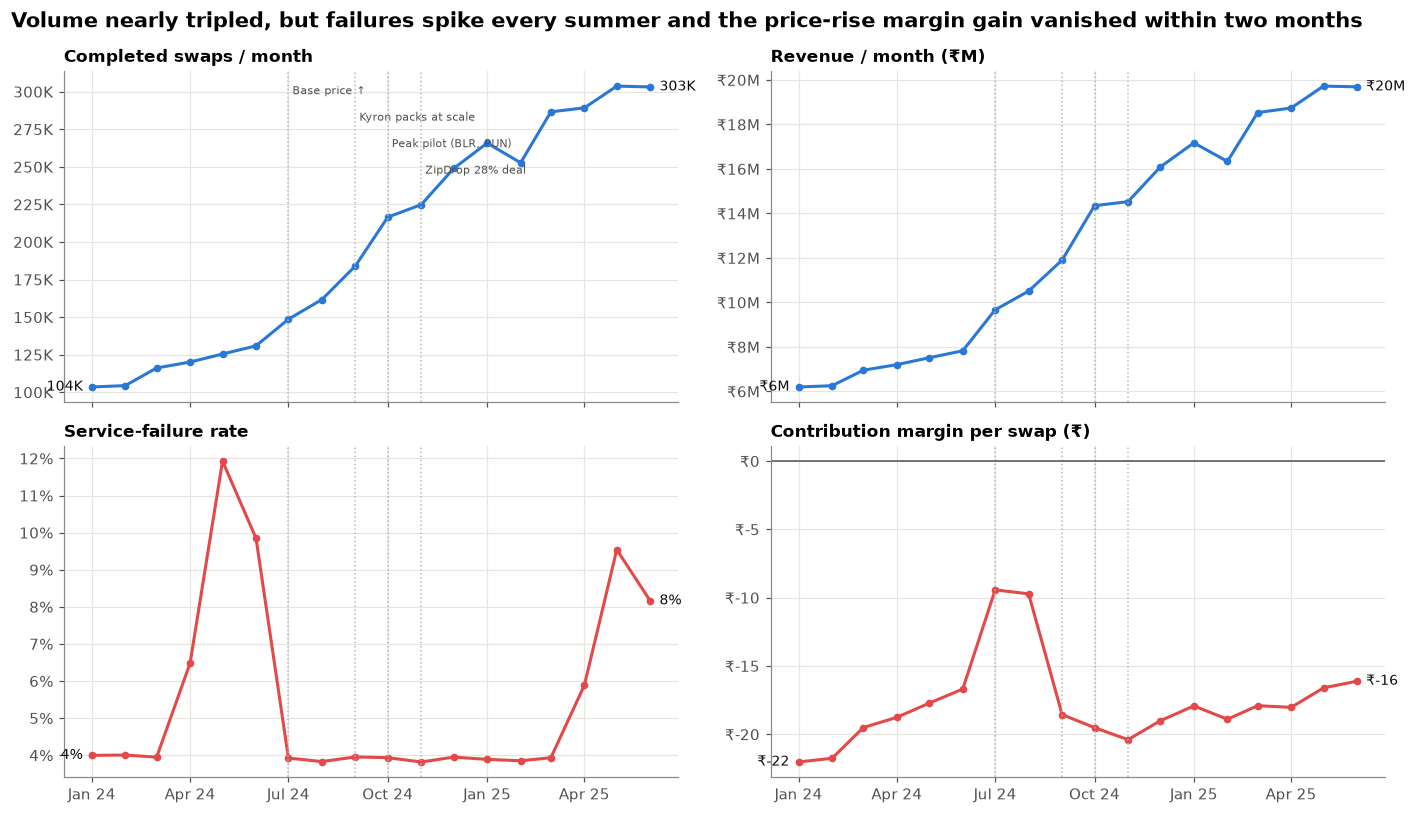

H1-2025 vs H1-2024: failures ×2.07, completed swaps ×2.43; no month of 2025 had a higher failure rate than the same month of 2024


,m,attempts,completed,fail_rate,no_batt_rate,revenue_m,arps,energy,wear,fixed,cm
0,2024-01-01,108278,"103,508.00",4.00,2.44,6.20,59.89,22.01,39.53,20.38,-22.03
1,2024-02-01,109271,"104,437.00",4.01,2.40,6.26,59.90,21.90,39.57,20.19,-21.76
2,2024-03-01,121487,"116,148.00",3.95,2.37,6.95,59.86,21.71,39.49,18.16,-19.50
3,2024-04-01,128991,"120,117.00",6.48,4.13,7.20,59.98,21.60,39.58,17.56,-18.76
4,2024-05-01,143189,"125,454.00",11.93,7.82,7.51,59.89,21.33,39.47,16.81,-17.72
5,2024-06-01,145880,"130,880.00",9.85,6.43,7.83,59.81,21.03,39.35,16.11,-16.69
6,2024-07-01,155343,"148,611.00",3.92,2.35,9.67,65.05,20.86,39.43,14.19,-9.43
7,2024-08-01,168900,"161,688.00",3.83,2.29,10.51,65.00,20.65,39.40,14.67,-9.72
8,2024-09-01,192479,"184,051.00",3.95,2.39,11.90,64.67,20.46,48.93,13.85,-18.56
9,2024-10-01,226458,"216,551.00",3.93,2.38,14.35,66.26,20.23,52.40,13.15,-19.51


In [15]:
mon = q('''SELECT DATE_TRUNC('month', ts) m, COUNT(*) attempts, SUM(done) completed, 100*AVG(fail) fail_rate,
                  100*AVG((event_type='failed_no_charged_battery')::INT) no_batt_rate, SUM(rev)/1e6 revenue_m
           FROM sw GROUP BY 1 ORDER BY 1''')
cmm = q('''SELECT DATE_TRUNC('month', ts) m, AVG(rev) arps, AVG(energy_cost) energy, AVG(wear_cost) wear, AVG(fixed_cost) fixed, AVG(cm) cm FROM swc GROUP BY 1 ORDER BY 1''')
mon = mon.merge(cmm, on="m"); mon["m"] = pd.to_datetime(mon.m)
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), sharex=True)
panels = [("completed", "Completed swaps / month", BLUE, lambda v: f"{v/1e3:.0f}K"), ("revenue_m", "Revenue / month (₹M)", BLUE, lambda v: f"₹{v:.0f}M"),
          ("fail_rate", "Service-failure rate", RED, lambda v: f"{v:.0f}%"), ("cm", "Contribution margin per swap (₹)", RED, lambda v: f"₹{v:.0f}")]
for ax, (col, title, c, fmt) in zip(axes.flat, panels):
    ax.plot(mon.m, mon[col], color=c, marker="o", ms=4); ax.set_title(title, fontsize=11)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _, fmt=fmt: fmt(v))); date_axis(ax)
    for d, lab in EVENTS.items(): ax.axvline(pd.Timestamp(d), color=GREY, lw=1, ls=":")
    first, last = mon[col].iloc[0], mon[col].iloc[-1]
    ax.annotate(fmt(last), (mon.m.iloc[-1], last), xytext=(6, 0), textcoords="offset points", va="center", fontsize=9, color=INK)
    ax.annotate(fmt(first), (mon.m.iloc[0], first), xytext=(-6, 0), textcoords="offset points", va="center", ha="right", fontsize=9, color=INK)
axes[1,1].axhline(0, color=INK2, lw=1)
ylo, yhi = axes[0,0].get_ylim()
for i, (d, lab) in enumerate(sorted(EVENTS.items())):
    axes[0,0].text(pd.Timestamp(d), yhi - (0.07 + 0.08*i)*(yhi-ylo), " " + lab, fontsize=7.5, color=INK2)
fig.suptitle("Volume nearly tripled, but failures spike every summer and the price-rise margin gain vanished within two months", x=0.01, ha="left", fontsize=14, fontweight="bold")
fig.tight_layout(); save(fig, "f01_performance_trend")
h1 = mon[mon.m < "2024-07-01"]; h2 = mon[mon.m >= "2025-01-01"]
keep("swaps_jan24", mon.completed.iloc[0]); keep("swaps_jun25", mon.completed.iloc[-1]); keep("swap_growth_x", mon.completed.iloc[-1] / mon.completed.iloc[0])
keep("rev_jan24_m", mon.revenue_m.iloc[0]); keep("rev_jun25_m", mon.revenue_m.iloc[-1])
keep("cm_h1_2024", (h1.cm*h1.completed).sum()/h1.completed.sum()); keep("cm_h1_2025", (h2.cm*h2.completed).sum()/h2.completed.sum())
keep("fail_peak_may24", mon.loc[mon.m=="2024-05-01","fail_rate"].iloc[0]); keep("fail_peak_may25", mon.loc[mon.m=="2025-05-01","fail_rate"].iloc[0])
keep("fail_nonsummer", q("SELECT 100*AVG(fail) f FROM sw WHERE MONTH(ts) NOT IN (4,5,6)").f[0]); keep("fail_summer", q("SELECT 100*AVG(fail) f FROM sw WHERE MONTH(ts) IN (4,5,6)").f[0])
# The brief says failures "rose faster" than swaps. Same-half-year comparison says otherwise.
yy = q("SELECT YEAR(ts) yr, SUM(done) comp, SUM(fail) fails FROM sw WHERE MONTH(ts) <= 6 GROUP BY 1").set_index("yr")
keep("h1_fail_count_growth_x", yy.fails[2025] / yy.fails[2024]); keep("h1_completed_growth_x", yy.comp[2025] / yy.comp[2024])
print(f"H1-2025 vs H1-2024: failures ×{METRICS['h1_fail_count_growth_x']:.2f}, completed swaps ×{METRICS['h1_completed_growth_x']:.2f}; no month of 2025 had a higher failure rate than the same month of 2024")
mon.round(2)

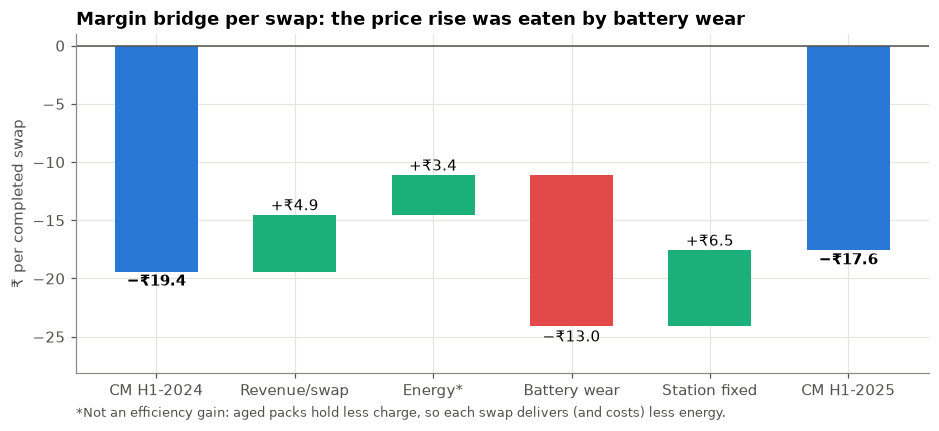

Energy per 2W swap fell 2.02 → 1.69 kWh as returned-pack SoH fell 97% → 81%
H1-2025 CM per swap: -17.5 as modelled vs -4.2 if the Kyron 2W packs had worn like Cellora (76% of the loss is that one batch)


In [16]:
# Where did the margin go? Per-swap bridge, H1 2024 vs H1 2025
a = cmm[pd.to_datetime(cmm.m) < "2024-07-01"].mean(numeric_only=True); b = cmm[pd.to_datetime(cmm.m) >= "2025-01-01"].mean(numeric_only=True)
steps = [("CM H1-2024", a.cm), ("Revenue/swap", b.arps-a.arps), ("Energy*", -(b.energy-a.energy)), ("Battery wear", -(b.wear-a.wear)), ("Station fixed", -(b.fixed-a.fixed)), ("CM H1-2025", b.cm)]
fig, ax = plt.subplots(figsize=(10, 4)); run = 0
for i, (lab, v) in enumerate(steps):
    if i in (0, len(steps)-1): ax.bar(i, v, color=BLUE, width=0.6); ax.text(i, v + (0.4 if v >= 0 else -1.2), f"{chr(8722) if v < 0 else chr(32)}₹{abs(v):.1f}".strip(), ha="center", fontsize=10, fontweight="bold"); run = v
    else:
        ax.bar(i, abs(v), bottom=min(run, run+v), color=AQUA if v >= 0 else RED, width=0.6)
        ax.text(i, (max(run, run+v) + 0.4) if v >= 0 else (min(run, run+v) - 1.3), f"{'+' if v>=0 else '−'}₹{abs(v):.1f}", ha="center", fontsize=10); run += v
ax.set_xticks(range(len(steps))); ax.set_xticklabels([s[0] for s in steps]); ax.axhline(0, color=INK2, lw=1)
lows = np.cumsum([steps[0][1]] + [v for _, v in steps[1:-1]]); ax.set_ylim(min(lows.min(), steps[0][1]) - 4, 1)
ax.set_title("Margin bridge per swap: the price rise was eaten by battery wear"); ax.set_ylabel("₹ per completed swap")
ax.text(0, -0.13, "*Not an efficiency gain: aged packs hold less charge, so each swap delivers (and costs) less energy.", transform=ax.transAxes, fontsize=8.5, color=INK2)
save(fig, "f03_margin_bridge")
for lab, v in steps: keep("bridge_" + lab.replace("*", "").replace(" ", "_").replace("/", "_").replace("-", "_").lower(), v)
en = q('''SELECT (ts >= '2025-01-01') h125, AVG(kwh) kwh, AVG(soh_in) soh FROM sw WHERE done=1 AND pack_in LIKE '2W%' AND (ts < '2024-07-01' OR ts >= '2025-01-01') GROUP BY 1''').set_index("h125")
keep("kwh_2w_h1_24", en.kwh.loc[False]); keep("kwh_2w_h1_25", en.kwh.loc[True]); keep("soh_2w_h1_24", en.soh.loc[False]); keep("soh_2w_h1_25", en.soh.loc[True])
# How much of the H1-2025 loss is the bad Kyron batch? Re-price those swaps at Cellora's wear rate.
cell2w = float(q("SELECT w FROM wear_rate WHERE supplier='Cellora' AND pack_type='2W_2.1kWh'").w[0])
cf = q(f"SELECT AVG(cm) a, AVG(cm + CASE WHEN sup_in='Kyron' AND pack_in LIKE '2W%' THEN wear_cost - {cell2w} ELSE 0 END) b FROM swc WHERE ts >= '2025-01-01'").iloc[0]
keep("cm_h1_25_without_bad_lots", cf.b); keep("cm_gap_share_from_bad_lots", 100 * (cf.b - cf.a) / -cf.a)
print(f"Energy per 2W swap fell {METRICS['kwh_2w_h1_24']:.2f} → {METRICS['kwh_2w_h1_25']:.2f} kWh as returned-pack SoH fell {METRICS['soh_2w_h1_24']:.0f}% → {METRICS['soh_2w_h1_25']:.0f}%")
print(f"H1-2025 CM per swap: {cf.a:.1f} as modelled vs {cf.b:.1f} if the Kyron 2W packs had worn like Cellora ({METRICS['cm_gap_share_from_bad_lots']:.0f}% of the loss is that one batch)")

### ✅ Finding: Q1. The metrics do not tell the same story
- **Volume and revenue:** completed swaps grew **2.9×** (104K → 303K per month) and monthly revenue **₹6.2M → ₹19.7M**. The growth was steady and never paused.
- **Failures:** flat at ~**3.9%** for nine months of each year, spiking every **April–June** (11.9% in May 2024, 9.5% in May 2025). Summer attempts fail **8.4%** of the time vs 3.9% otherwise. Contrary to the brief, failures did **not** rise faster than swaps: in H1-2025 vs H1-2024 failure counts grew **2.1×** while completed swaps grew **2.4×**, and no month of 2025 was worse than the same month of 2024. This is a *seasonal capacity* problem that has not been fixed, not a gradual decline.
- **Contribution margin per swap (fully loaded):** improved from −₹19.2 (H1-2024) to −₹9.6 after the July-2024 price rise, then **fell straight back to −₹18.2 from September 2024**, the month the bad Kyron lots entered service. The margin bridge shows **+₹4.9 from price and +₹6.5 from spreading site costs over more swaps, almost fully eaten by −₹13.0 of extra battery wear**. The +₹3.4 'energy' step is not a gain: energy per swap fell from 2.02 to 1.69 kWh because aged packs hold less charge.
- **How much is one cohort?** Re-pricing the bad-lot swaps at a normal pack's wear rate moves H1-2025 margin from −₹17.5 to **−₹4.2** per swap: about **76%** of the loss is those three lots.
- The absolute CM level depends on the battery-wear assumption (with 30% salvage value, CM went **+₹2.3 → −₹2.5**). The **direction and the driver are the same under every assumption**: before battery wear, margin per swap rose from ₹20 to ₹34.

## 7. Core Question 2: Service Failures and Customer Experience

In [17]:
mix = q('''SELECT CASE WHEN MONTH(ts) IN (4,5,6) THEN 'Summer (Apr–Jun)' ELSE 'Rest of year' END season, event_type, COUNT(*) n FROM sw WHERE event_type<>'swap_completed' GROUP BY ALL''')
mix_p = mix.pivot(index="season", columns="event_type", values="n")
tot = q("SELECT CASE WHEN MONTH(ts) IN (4,5,6) THEN 'Summer (Apr–Jun)' ELSE 'Rest of year' END season, COUNT(*) n FROM sw GROUP BY 1").set_index("season").n
(100 * mix_p.div(tot, axis=0)).round(2)

event_type,abandoned_queue,cancelled_by_rider,failed_no_charged_battery,failed_system_error
season,,,,
Rest of year,1.26,0.43,2.35,0.30
Summer (Apr–Jun),2.66,0.44,5.45,0.30


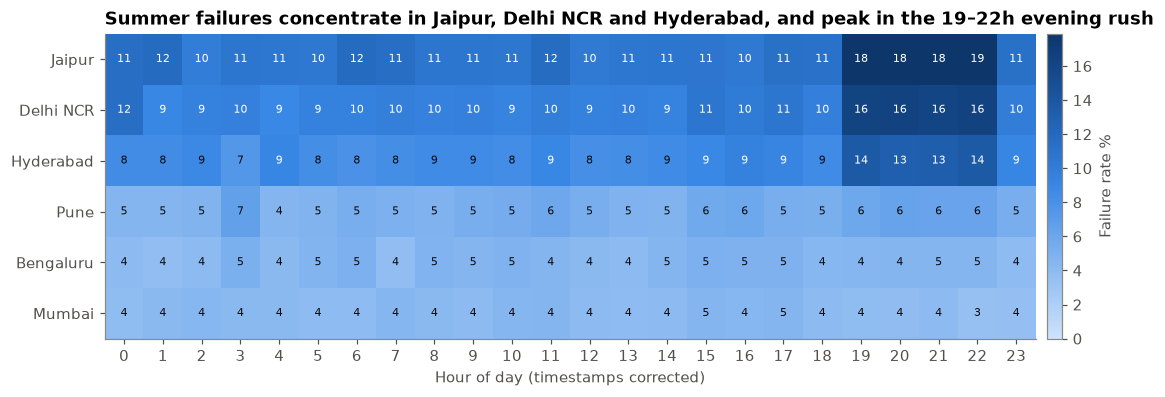

In [18]:
hc = q('''SELECT city, HOUR(ts) h, 100*AVG(fail) f FROM sw WHERE MONTH(ts) IN (4,5,6) GROUP BY ALL''').pivot(index="city", columns="h", values="f")
hc = hc.loc[hc.mean(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(13, 3.6))
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("seq", SEQ)
im = ax.imshow(hc.values, aspect="auto", cmap=cmap, vmin=0, vmax=np.nanpercentile(hc.values, 98))
ax.set_yticks(range(len(hc))); ax.set_yticklabels(hc.index); ax.set_xticks(range(24)); ax.set_xticklabels(range(24)); ax.grid(False)
for i in range(hc.shape[0]):
    for j in range(hc.shape[1]):
        v = hc.values[i, j]; ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7, color="white" if v > np.nanpercentile(hc.values, 60) else INK)
ax.set_xlabel("Hour of day (timestamps corrected)"); cb = fig.colorbar(im, ax=ax, pad=0.01); cb.set_label("Failure rate %")
ax.set_title("Summer failures concentrate in Jaipur, Delhi NCR and Hyderabad, and peak in the 19–22h evening rush")
save(fig, "f04_failure_heatmap")

In [19]:
vc = q('''SELECT vc, CASE WHEN MONTH(ts) IN (4,5,6) THEN 'summer' ELSE 'rest' END season, 100*AVG(fail) f, 100*AVG((event_type='failed_no_charged_battery')::INT) nb,
          100*AVG((event_type='abandoned_queue')::INT) ab, AVG(queue_wait_sec) FILTER (WHERE done=1) wait_ok, AVG(queue_wait_sec) FILTER (WHERE event_type='abandoned_queue') wait_abandon FROM sw GROUP BY ALL ORDER BY 1,2''')
keep("fail_3w_summer", vc.query("vc=='3W' and season=='summer'").f.iloc[0]); keep("fail_2w_summer", vc.query("vc=='2W' and season=='summer'").f.iloc[0])
keep("fail_3w_rest", vc.query("vc=='3W' and season=='rest'").f.iloc[0]); keep("fail_2w_rest", vc.query("vc=='2W' and season=='rest'").f.iloc[0])
# Is the 3W gap about stations without 3W slots? No: 3W riders fail equally at both, and most 3W swaps happen at 'zero-slot' stations (a field to distrust)
s3 = q('''SELECT 100*AVG(fail) FILTER (WHERE slots_3w>0) with_slots, 100*AVG(fail) FILTER (WHERE slots_3w=0) no_slots,
          100*SUM(done) FILTER (WHERE slots_3w=0)/SUM(done) pct_done_at_no_slot FROM sw WHERE vc='3W' AND MONTH(ts) IN (4,5,6)''').iloc[0]
keep("fail_3w_summer_slot", s3.with_slots); keep("fail_3w_summer_noslot", s3.no_slots)
keep("anom_3w_no_slot_pct", q("SELECT 100*AVG((slots_3w=0)::INT) p FROM sw WHERE vc='3W' AND done=1").p[0])
print(f"3W summer failure: {s3.with_slots:.1f}% at stations with 3W slots vs {s3.no_slots:.1f}% at stations listed with none; "
      f"outside summer 3W still fails {METRICS['fail_3w_rest']:.1f}% vs {METRICS['fail_2w_rest']:.1f}% for 2W (a year-round gap)")
vc

3W summer failure: 12.2% at stations with 3W slots vs 12.2% at stations listed with none; outside summer 3W still fails 8.6% vs 3.3% for 2W (a year-round gap)


,vc,season,f,nb,ab,wait_ok,wait_abandon
0,2W,rest,3.34,1.97,1.07,243.87,704.77
1,2W,summer,7.93,5.13,2.51,243.64,701.46
2,3W,rest,8.62,5.47,2.85,242.85,701.17
3,3W,summer,12.23,8.03,3.87,243.54,704.11


Worst 20% of stations: 31% of attempts, 43% of failures. Hot-city Gen1 stations: 32% of summer attempts, 57.5% of summer failures


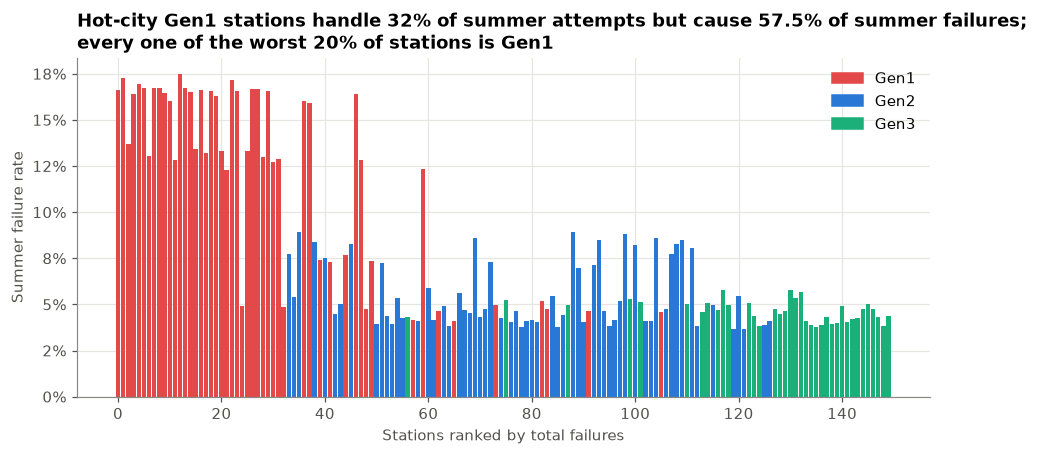

,station_id,city,gen,location_type,wave,attempts,fails,fail_rate,summer_fail,cum_share,station_share
0,STN-DEL-043,Delhi NCR,Gen1,commercial_hub,Launch,49597,"4,060.00",8.19,16.64,1.92,0.67
1,STN-JAI-138,Jaipur,Gen1,market,Launch,48945,"4,024.00",8.22,17.29,3.82,1.33
2,STN-HYD-072,Hyderabad,Gen1,commercial_hub,Launch,51765,"3,962.00",7.65,13.69,5.69,2.00
3,STN-DEL-050,Delhi NCR,Gen1,commercial_hub,Launch,47060,"3,849.00",8.18,16.39,7.50,2.67
4,STN-JAI-141,Jaipur,Gen1,commercial_hub,Launch,45594,"3,796.00",8.33,16.96,9.29,3.33
5,STN-JAI-137,Jaipur,Gen1,commercial_hub,Launch,44371,"3,690.00",8.32,16.72,11.04,4.00
6,STN-HYD-070,Hyderabad,Gen1,market,Launch,49688,"3,561.00",7.17,13.05,12.72,4.67
7,STN-JAI-140,Jaipur,Gen1,commercial_hub,Launch,44115,"3,552.00",8.05,16.75,14.39,5.33
8,STN-JAI-134,Jaipur,Gen1,commercial_hub,Launch,42925,"3,419.00",7.97,16.73,16.01,6.00
9,STN-DEL-047,Delhi NCR,Gen1,market,Launch,41594,"3,331.00",8.01,16.48,17.58,6.67


In [20]:
# Concentration: Pareto of failures across stations
st = q('''SELECT station_id, city, gen, location_type, wave, COUNT(*) attempts, SUM(fail) fails, 100*AVG(fail) fail_rate,
          100*AVG(fail) FILTER (WHERE MONTH(ts) IN (4,5,6)) summer_fail FROM sw GROUP BY ALL ORDER BY fails DESC''')
st["cum_share"] = 100 * st.fails.cumsum() / st.fails.sum(); st["station_share"] = 100 * np.arange(1, len(st)+1) / len(st)
top20 = st.head(int(0.2 * len(st)))
keep("top20pct_station_fail_share", top20.fails.sum() / st.fails.sum() * 100); keep("top20_gen1_share", 100*(top20.gen == "Gen1").mean())
# Exposure check: these stations were open all 18 months and are busy, so compare failure share with attempt share
keep("top20_att_share", 100 * top20.attempts.sum() / st.attempts.sum())
hotg = q('''SELECT 100*SUM(fail) FILTER (WHERE gen='Gen1' AND city IN ('Jaipur','Delhi NCR','Hyderabad'))/SUM(fail) f,
            100*AVG((gen='Gen1' AND city IN ('Jaipur','Delhi NCR','Hyderabad'))::INT) a FROM sw WHERE MONTH(ts) IN (4,5,6)''').iloc[0]
keep("hot_gen1_summer_fail_share", hotg.f); keep("hot_gen1_summer_att_share", hotg.a)
print(f"Worst 20% of stations: {METRICS['top20_att_share']:.0f}% of attempts, {METRICS['top20pct_station_fail_share']:.0f}% of failures. "
      f"Hot-city Gen1 stations: {hotg.a:.0f}% of summer attempts, {hotg.f:.1f}% of summer failures")
fig, ax = plt.subplots(figsize=(10, 4))
cols = [RED if g == "Gen1" else (BLUE if g == "Gen2" else AQUA) for g in st.gen]
ax.bar(range(len(st)), st.summer_fail, color=cols, width=0.85)
ax.set_xlabel("Stations ranked by total failures"); ax.set_ylabel("Summer failure rate"); pct_axis(ax)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=RED, label="Gen1"), Patch(color=BLUE, label="Gen2"), Patch(color=AQUA, label="Gen3")], loc="upper right")
ax.set_title(f"Hot-city Gen1 stations handle {hotg.a:.0f}% of summer attempts but cause {hotg.f:.1f}% of summer failures;\nevery one of the worst 20% of stations is Gen1")
save(fig, "f05_station_pareto")
st.head(12)

In [21]:
# Link failures to stock: hourly telemetry says whether the cabinet actually ran out
lk = q('''WITH hf AS (SELECT station_id, DATE_TRUNC('hour', ts) hr, COUNT(*) n, SUM(fail) f, SUM((event_type='failed_no_charged_battery')::INT) nb FROM sw GROUP BY ALL)
          SELECT CASE WHEN h.charged_2w_min = 0 THEN 'stock hit 0' WHEN h.charged_2w_min <= 2 THEN '1–2 packs' ELSE '3+ packs' END stock, SUM(hf.n) attempts,
          100*SUM(hf.f)/SUM(hf.n) fail_rate, 100*SUM(hf.nb)/SUM(hf.n) no_battery_rate
          FROM hf JOIN sh h ON h.station_id=hf.station_id AND h.hour_start=hf.hr WHERE h.telemetry_status<>'missing' GROUP BY 1 ORDER BY 1''')
lk

,stock,attempts,fail_rate,no_battery_rate
0,1–2 packs,"258,279.00",6.76,4.28
1,3+ packs,"3,473,344.00",5.37,3.36
2,stock hit 0,"57,694.00",11.21,7.27


**What does a failure cost?** If a failed rider simply came back an hour later, a failure would cost experience but not revenue. They don't: a rider's next attempt after a failure comes exactly when it would after a successful swap, so each failure is a lost sale.

In [22]:
rt = q('''WITH x AS (SELECT fail, done, ts, LEAD(ts) OVER w nts, LEAD(done) OVER w ndone FROM sw WINDOW w AS (PARTITION BY rider_id ORDER BY ts))
          SELECT CASE WHEN fail=1 THEN 'after a failed attempt' ELSE 'after a completed swap' END after_event, COUNT(*) n,
                 100*AVG((ndone=1 AND EPOCH(nts-ts)<=3600)::INT) pct_completed_within_1h, MEDIAN(EPOCH(nts-ts)/3600) median_hours_to_next
          FROM x WHERE fail=1 OR done=1 GROUP BY 1''').set_index("after_event")
lost = q("SELECT vc, SUM(fail) fails, AVG(rev) FILTER (WHERE done=1) arps FROM sw GROUP BY 1")
keep("retry_within_1h_pct", rt.loc["after a failed attempt", "pct_completed_within_1h"]); keep("failure_revenue_lost_m_18mo", (lost.fails * lost.arps).sum() / 1e6)
print(f"Revenue not collected on failed attempts over 18 months: ≈₹{METRICS['failure_revenue_lost_m_18mo']:.1f}M")
rt.round(2)

Revenue not collected on failed attempts over 18 months: ≈₹14.3M


,n,pct_completed_within_1h,median_hours_to_next
after_event,,,
after a failed attempt,211849,4.56,21.52
after a completed swap,3586675,4.56,21.53


### ✅ Finding: Q2. Service quality is highly concentrated
- **When:** in summer the 'no charged battery' rate more than doubles (2.4% → 5.5%) and queue abandonment doubles (1.3% → 2.7%). System errors and rider cancellations do **not** change with season, which points to supply (charged packs), not software.
- **Where:** Jaipur, Delhi NCR and Hyderabad carry the summer spike; Bengaluru and Mumbai barely move. Within those cities failures run at 9–12% all day in summer and jump to **13–19% in the 19–22h evening rush**, when demand peaks on cabinets that have spent the hot afternoon charging slowly.
- **Concentration:** the **36 hot-city Gen1 stations handle 32% of summer attempts but cause 57.5% of summer failures**. Ranked by total failures, the worst 20% of stations are all Gen1 launch sites (43% of failures from 31% of attempts). When a cabinet's hourly minimum stock hits zero, the failure rate doubles (11.2% vs 5.4%), which confirms the 'empty cabinet' mechanism.
- **Who:** 3W riders fail more (12.2% in summer vs 7.9% for 2W), and the gap exists all year (8.6% vs 3.3% outside summer). It is **not** explained by 3W slot availability: 3W failure is identical at stations with and without listed 3W slots, and that field is unreliable. 3W stock is a separate issue worth a dedicated review.
- **Cost:** a rider's next attempt after a failure comes exactly when it would after a successful swap, so each failure is a lost sale: **≈₹14.3M** of revenue over 18 months.
- *Note:* average queue wait is flat (~244 s) for completed swaps. Congestion shows up as **abandonment** (riders leave after ~12 min), not as longer successful waits.

## 8. Core Question 3: Station and Geographic Patterns

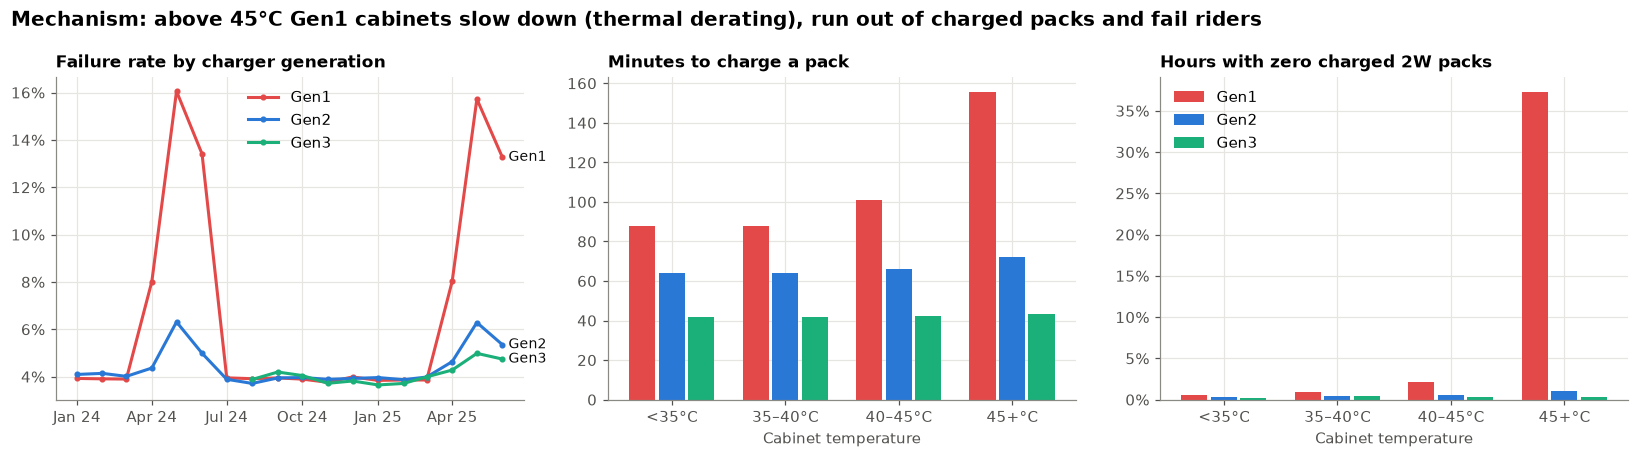

Hot-city Gen1, summer: failure rate 4.1% on days whose cabinet peak stays under 43°C vs 18.7% once it passes 46°C


charge_min             stockout_pct          
gen         Gen1  Gen2  Gen3         Gen1 Gen2 Gen3
band                                               
<35        88.00 64.00 42.00         0.60 0.40 0.20
35–40      88.00 64.00 42.00         0.90 0.50 0.40
40–45     101.10 66.00 42.30         2.10 0.60 0.30
45+       155.60 72.10 43.50        37.30 1.00 0.30

In [23]:
gm = q('''SELECT DATE_TRUNC('month', ts) m, gen, 100*AVG(fail) f FROM sw GROUP BY ALL ORDER BY 1''').pivot(index="m", columns="gen", values="f")
tb = q('''SELECT gen, CASE WHEN cabinet_temp_c<35 THEN '<35' WHEN cabinet_temp_c<40 THEN '35–40' WHEN cabinet_temp_c<45 THEN '40–45' ELSE '45+' END band,
          COUNT(*) n_hours, AVG(avg_charge_minutes) charge_min, 100*AVG((charged_2w_min=0)::INT) stockout_pct
          FROM sh WHERE telemetry_status='ok' AND cabinet_temp_c IS NOT NULL GROUP BY ALL''')
order = ["<35", "35–40", "40–45", "45+"]; gcol = {"Gen1": RED, "Gen2": BLUE, "Gen3": AQUA}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
ax = axes[0]
for g in ["Gen1", "Gen2", "Gen3"]:
    ax.plot(pd.to_datetime(gm.index), gm[g], color=gcol[g], marker="o", ms=3, label=g)
    ax.annotate(g, (pd.to_datetime(gm.index[-1]), gm[g].iloc[-1]), xytext=(4, 0), textcoords="offset points", color=INK, fontsize=9, va="center")
pct_axis(ax); date_axis(ax); ax.set_title("Failure rate by charger generation", fontsize=11); ax.legend(loc="upper center")
for ax, col, ttl in [(axes[1], "charge_min", "Minutes to charge a pack"), (axes[2], "stockout_pct", "Hours with zero charged 2W packs")]:
    x = np.arange(len(order)); wdt = 0.26
    for i, g in enumerate(["Gen1", "Gen2", "Gen3"]):
        d = tb[tb.gen == g].set_index("band").reindex(order)
        ax.bar(x + (i-1)*wdt, d[col], width=wdt-0.03, color=gcol[g], label=g)
    ax.set_xticks(x); ax.set_xticklabels([f"{o}°C" for o in order]); ax.set_xlabel("Cabinet temperature"); ax.set_title(ttl, fontsize=11)
    if col == "stockout_pct": pct_axis(ax)
axes[2].legend()
fig.suptitle("Mechanism: above 45°C Gen1 cabinets slow down (thermal derating), run out of charged packs and fail riders", x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout(); save(fig, "f06_heat_mechanism")
g1 = tb[(tb.gen=="Gen1")].set_index("band"); g3 = tb[(tb.gen=="Gen3")].set_index("band")
keep("gen1_charge_min_cool", g1.loc["<35","charge_min"]); keep("gen1_charge_min_hot", g1.loc["45+","charge_min"]); keep("gen1_stockout_hot", g1.loc["45+","stockout_pct"])
keep("gen3_charge_min_hot", g3.loc["45+","charge_min"]); keep("gen3_stockout_hot", g3.loc["45+","stockout_pct"])
gs = q("SELECT gen, 100*AVG(fail) FILTER (WHERE MONTH(ts) IN (4,5,6)) summer, 100*AVG(fail) FILTER (WHERE MONTH(ts) NOT IN (4,5,6)) rest FROM sw GROUP BY 1").set_index("gen")
keep("gen1_summer_fail", gs.loc["Gen1","summer"]); keep("gen3_summer_fail", gs.loc["Gen3","summer"]); keep("gen1_rest_fail", gs.loc["Gen1","rest"])
# Failures lag the heat (cabinets drain in the hot afternoon, riders fail in the evening), so link failures to each station-day's PEAK cabinet temperature
dayt = q('''WITH a AS (SELECT station_id, ts::DATE dy, COUNT(*) n, SUM(fail) f FROM sw WHERE gen='Gen1' AND city IN ('Jaipur','Delhi NCR','Hyderabad') AND MONTH(ts) IN (4,5,6) GROUP BY ALL),
                 t AS (SELECT station_id, hour_start::DATE dy, MAX(cabinet_temp_c) tmax FROM sh GROUP BY ALL)
            SELECT FLOOR(t.tmax)::INT t, SUM(a.n) n, SUM(a.f) f FROM a JOIN t USING(station_id, dy) WHERE t.tmax IS NOT NULL GROUP BY 1 ORDER BY 1''')
dayt = dayt[dayt.n >= 500].reset_index(drop=True)
keep("gen1_day_fail_below43", 100 * dayt[dayt.t < 43].f.sum() / dayt[dayt.t < 43].n.sum()); keep("gen1_day_fail_46plus", 100 * dayt[dayt.t >= 46].f.sum() / dayt[dayt.t >= 46].n.sum())
print(f"Hot-city Gen1, summer: failure rate {METRICS['gen1_day_fail_below43']:.1f}% on days whose cabinet peak stays under 43°C vs {METRICS['gen1_day_fail_46plus']:.1f}% once it passes 46°C")
tb.pivot(index="band", columns="gen", values=["charge_min", "stockout_pct"]).reindex(order).round(1)

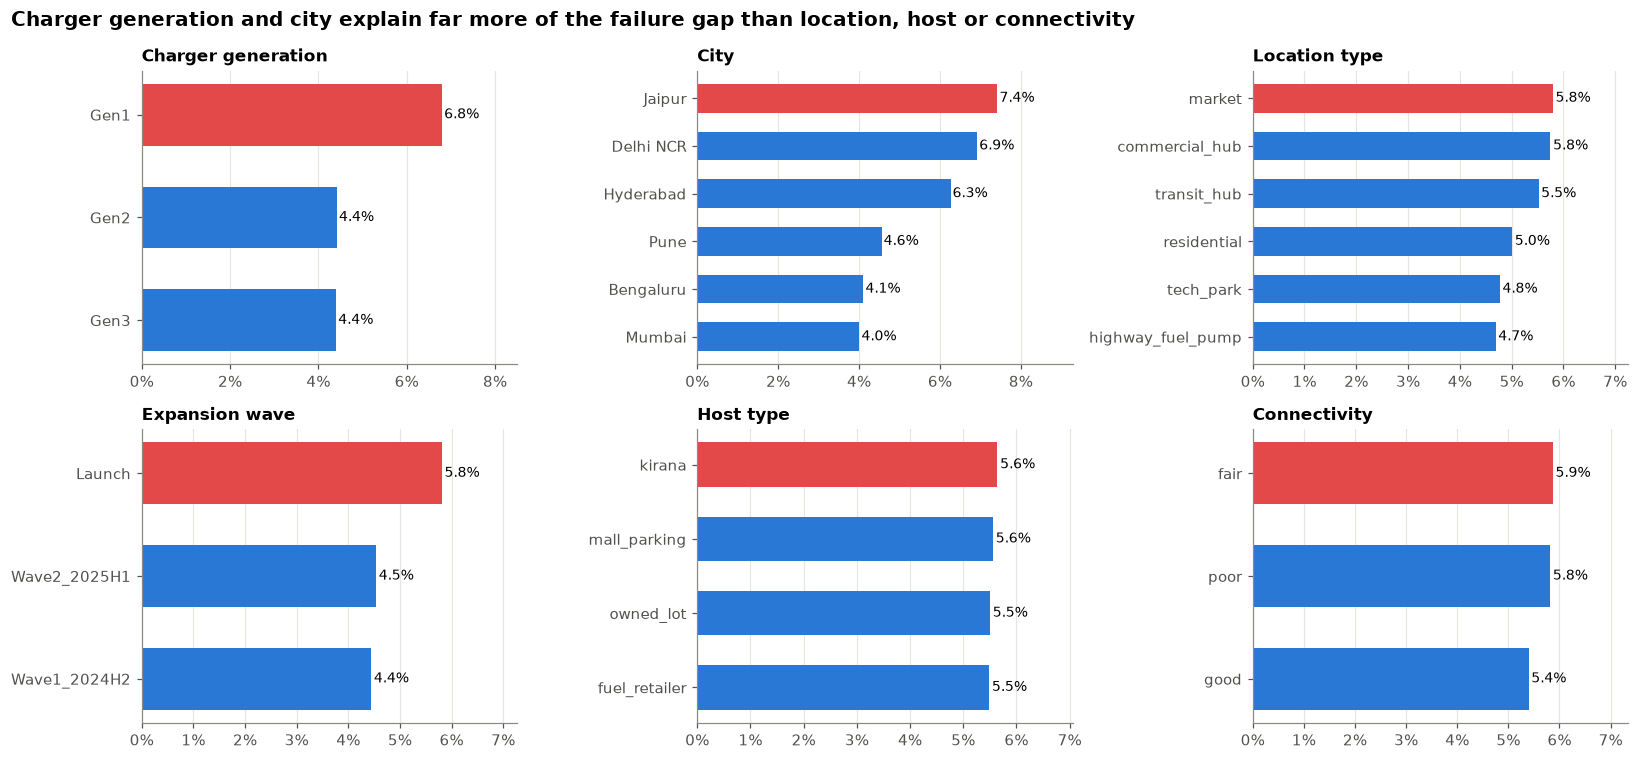

,level,stations,fail_rate,charge_min,summer_cabinet_c,tickets_per_1k
0,Gen1,51,6.80,91.81,33.45,12.66
1,Gen2,62,4.42,64.25,31.83,9.92
2,Gen3,37,4.40,42.15,32.81,12.64


,level,stations,fail_rate,charge_min,summer_cabinet_c,tickets_per_1k
0,Jaipur,18,7.42,75.20,35.63,14.51
1,Delhi NCR,30,6.92,72.18,35.40,13.88
2,Hyderabad,26,6.26,71.83,33.52,12.91
3,Pune,22,4.56,62.64,31.33,9.57
4,Bengaluru,32,4.11,66.08,29.72,9.11
5,Mumbai,22,4.01,61.21,30.82,8.90


In [24]:
# Station attributes side by side: failure, turnaround and complaints per 1,000 swaps
tpk = q("SELECT station_id, COUNT(*) tickets FROM tk WHERE station_id IS NOT NULL GROUP BY 1")
con.register("tpk", tpk)
def by(dim):
    return q(f'''WITH a AS (SELECT station_id, COUNT(*) n, SUM(done) c, SUM(fail) f FROM sw GROUP BY 1),
                 t AS (SELECT station_id, AVG(avg_charge_minutes) chg, AVG(cabinet_temp_c) FILTER (WHERE MONTH(hour_start) IN (4,5,6)) temp_summer FROM sh GROUP BY 1)
                 SELECT s.{dim} AS level, COUNT(*) stations, 100*SUM(a.f)/SUM(a.n) fail_rate, AVG(t.chg) charge_min, AVG(t.temp_summer) summer_cabinet_c,
                        1000*SUM(COALESCE(tp.tickets,0))/SUM(a.c) tickets_per_1k
                 FROM stations s JOIN a USING(station_id) JOIN t USING(station_id) LEFT JOIN tpk tp USING(station_id) GROUP BY 1 ORDER BY fail_rate DESC''')
dims = {"charger_generation": "Charger generation", "city": "City", "location_type": "Location type", "expansion_wave": "Expansion wave", "host_type": "Host type", "connectivity_tier": "Connectivity"}
tabs = {k: by(k) for k in dims}
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (k, ttl) in zip(axes.flat, dims.items()):
    d = tabs[k].sort_values("fail_rate")
    ax.barh(d.level.astype(str), d.fail_rate, color=[RED if v == d.fail_rate.max() else BLUE for v in d.fail_rate], height=0.6)
    for i, v in enumerate(d.fail_rate): ax.text(v + 0.05, i, f"{v:.1f}%", va="center", fontsize=9)
    ax.set_title(ttl, fontsize=11); ax.set_xlim(0, d.fail_rate.max() * 1.25); pct_axis(ax, "x"); ax.grid(axis="y", visible=False)
fig.suptitle("Charger generation and city explain far more of the failure gap than location, host or connectivity", x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout(); save(fig, "f07_station_attributes")
for k in ["charger_generation", "city"]: display(tabs[k].round(2))

In [25]:
# Is it the generation or just the hot cities? Compare generations within the same city (summer)
gxc = q('''SELECT city, gen, COUNT(DISTINCT station_id) stations, 100*AVG(fail) summer_fail FROM sw WHERE MONTH(ts) IN (4,5,6) GROUP BY ALL''').pivot(index="city", columns="gen", values="summer_fail")
gxc.round(2)

gen,Gen1,Gen2,Gen3
city,,,
Bengaluru,4.83,4.31,4.08
Delhi NCR,16.53,8.37,5.30
Hyderabad,13.04,7.31,4.66
Jaipur,16.78,8.60,5.25
Mumbai,4.11,4.02,4.00
Pune,7.42,5.21,4.30


In [26]:
# Or is Gen1 just busier? Compare generations at the same load (hot cities, summer station-days, quartiles of attempts per charging slot)
ld = q('''WITH d AS (SELECT station_id, gen, ts::DATE dy, ANY_VALUE(slots_2w + COALESCE(slots_3w,0)) slots, COUNT(*) n, SUM(fail) f FROM sw
                     WHERE MONTH(ts) IN (4,5,6) AND city IN ('Jaipur','Delhi NCR','Hyderabad') GROUP BY ALL),
          e AS (SELECT *, NTILE(4) OVER (ORDER BY n/slots, station_id, dy) qt FROM d)
          SELECT qt load_quartile, gen, 100*SUM(f)/SUM(n) fail_rate, SUM(n)/SUM(slots) attempts_per_slot_day FROM e GROUP BY ALL ORDER BY 1,2''')
lp = ld.pivot(index="load_quartile", columns="gen", values="fail_rate")
keep("gen1_fail_min_quartile", lp["Gen1"].min()); keep("gen3_fail_max_quartile", lp["Gen3"].max())
busy = q('''SELECT gen, SUM(n)/SUM(nd*slots) v FROM (SELECT station_id, gen, ANY_VALUE(slots_2w+COALESCE(slots_3w,0)) slots, COUNT(*) n, COUNT(DISTINCT ts::DATE) nd
            FROM sw WHERE MONTH(ts) IN (4,5,6) AND city IN ('Jaipur','Delhi NCR','Hyderabad') GROUP BY ALL) GROUP BY 1''').set_index("gen").v
keep("load_gen1", busy["Gen1"]); keep("load_gen3", busy["Gen3"])
print(f"Gen1 fails {lp['Gen1'].min():.1f}–{lp['Gen1'].max():.1f}% in every load quartile vs {lp['Gen3'].min():.1f}–{lp['Gen3'].max():.1f}% for Gen3, "
      f"and Gen3 sites are busier ({busy['Gen3']:.1f} vs {busy['Gen1']:.1f} attempts per slot-day): the gap is the equipment, not the load")
lp.round(2)

Gen1 fails 14.4–15.8% in every load quartile vs 4.9–5.2% for Gen3, and Gen3 sites are busier (6.1 vs 4.3 attempts per slot-day): the gap is the equipment, not the load


gen,Gen1,Gen2,Gen3
load_quartile,,,
1,14.36,8.07,5.20
2,15.29,8.02,5.17
3,15.77,7.82,4.92
4,15.41,8.12,5.06


### ✅ Finding: Q3. Charger generation × climate is the station story
- **Gen1** stations fail **12.5%** of summer attempts vs **4.7%** at Gen3; outside summer all generations are equal (~3.9%). Gen1 is 48% of attempts but **58% of failures and 66% of summer failures**.
- **Mechanism:** Gen1 charge time is flat until 40°C, then climbs to **156 minutes** above 45°C, and stock-outs jump to **37% of hours**. Gen2 degrades mildly and Gen3 not at all. At station-day level the threshold is sharp: hot-city Gen1 stations fail **4.1%** of attempts on days whose cabinet peak stays under 43°C and **18.7%** once it passes 46°C.
- **Not just busier sites:** in hot-city summers Gen1 fails 14–16% in *every* load quartile vs about 5% for Gen3, and Gen3 sites are actually busier (6.1 vs 4.3 attempts per slot-day). Outages, offline chargers and quarantined packs are negligible for every generation.
- **Not just 'hot cities':** *within* Delhi NCR, Gen1 fails 16.5% in summer vs 5.3% at Gen3; Jaipur shows 16.8% vs 5.3%. In mild Bengaluru and Mumbai the generations perform the same. The fix is equipment, and it only matters where it is hot.
- Location type, host type and connectivity tier matter far less (±1 pt). Complaint rates follow the same ranking (Jaipur 14.5 and Delhi 13.9 tickets per 1,000 swaps vs Mumbai 8.9).

## 9. Core Question 4: Battery and Equipment Performance

In [27]:
bsum = q('''SELECT supplier, pack_type, COUNT(*) packs, AVG(initial_soh_pct) initial_soh, AVG(current_soh_pct) current_soh, MIN(commission_date) first_commissioned,
            SUM((retired_date IS NOT NULL)::INT) retired, ANY_VALUE(retirement_reason) FILTER (WHERE retirement_reason IS NOT NULL) reason FROM raw_batteries GROUP BY ALL ORDER BY 2,1''')
lots = q('''SELECT supplier, manufacturing_lot, pack_type, COUNT(*) packs, AVG(current_soh_pct) current_soh, SUM((retired_date IS NOT NULL)::INT) retired FROM raw_batteries GROUP BY ALL ORDER BY current_soh LIMIT 8''')
display(bsum.round(1)); display(lots.round(1))
# BMS firmware ruled out: Kyron is equally bad on every BMS version
display(q("SELECT supplier, bms_firmware, COUNT(*) packs, AVG(current_soh_pct) current_soh FROM raw_batteries GROUP BY ALL ORDER BY 1,2").pivot(index="supplier", columns="bms_firmware", values="current_soh").round(1))
kyr = q("SELECT COUNT(*) n, SUM(purchase_cost_inr) total_cost FROM raw_batteries WHERE supplier='Kyron' AND retired_date IS NOT NULL").iloc[0]
keep("kyron_retired_packs", int(kyr.n)); keep("kyron_writeoff_m", kyr.total_cost/1e6)
keep("kyron_2w_current_soh", bsum.query("supplier=='Kyron' and pack_type=='2W_2.1kWh'").current_soh.iloc[0])
keep("cellora_2w_current_soh", bsum.query("supplier=='Cellora' and pack_type=='2W_2.1kWh'").current_soh.iloc[0])

,supplier,pack_type,packs,initial_soh,current_soh,first_commissioned,retired,reason
0,Amptek,2W_2.1kWh,1098,99.20,80.00,2024-03-01,0.00,NaN
1,Cellora,2W_2.1kWh,3035,99.20,80.00,2023-03-01,0.00,NaN
2,Kyron,2W_2.1kWh,1385,99.20,60.50,2024-09-10,"1,385.00",end_of_life
3,Amptek,3W_4.8kWh,209,99.20,86.50,2024-03-01,0.00,NaN
4,Cellora,3W_4.8kWh,520,99.20,86.50,2023-03-01,0.00,NaN
5,Kyron,3W_4.8kWh,253,99.20,81.30,2024-07-01,53.00,end_of_life


,supplier,manufacturing_lot,pack_type,packs,current_soh,retired
0,Kyron,KY-2407,2W_2.1kWh,452,60.50,452.00
1,Kyron,KY-2408,2W_2.1kWh,471,60.50,471.00
2,Kyron,KY-2409,2W_2.1kWh,462,60.60,462.00
3,Kyron,KY-2407,3W_4.8kWh,28,68.70,24.00
4,Kyron,KY-2408,3W_4.8kWh,29,69.50,18.00
5,Kyron,KY-2409,3W_4.8kWh,19,69.50,11.00
6,Amptek,AM-2405,2W_2.1kWh,76,79.80,0.00
7,Amptek,AM-2501,2W_2.1kWh,78,79.80,0.00


bms_firmware,BMS-4.0,BMS-4.1,BMS-4.2
supplier,,,
Amptek,81.10,81.00,80.90
Cellora,80.90,81.00,80.90
Kyron,63.70,63.50,64.10


np.float64(79.97067545304782)

**Supplier or lot?** Kyron also made later 3W lots (KY-2410 to 2418). If Kyron itself were the problem, those would wear fast too.

In [28]:
lotw = q('''SELECT supplier, pack_type, CASE WHEN supplier<>'Kyron' THEN 'all lots' WHEN manufacturing_lot IN ('KY-2407','KY-2408','KY-2409') THEN 'lots KY-2407/08/09' ELSE 'lots KY-2410 to 2418' END lots,
            COUNT(*) packs, 1000*AVG(soh_loss_per_swap) soh_loss_per_1k_swaps, MEDIAN(wear_inr_per_swap) wear_inr_per_swap, SUM((retired_date IS NOT NULL)::INT) retired
            FROM bat_wear GROUP BY ALL ORDER BY 2,1,3''')
lw = lotw.set_index(["supplier", "pack_type", "lots"]).soh_loss_per_1k_swaps
keep("kyron_2w_bad_loss_1k", lw[("Kyron", "2W_2.1kWh", "lots KY-2407/08/09")]); keep("kyron_3w_later_loss_1k", lw[("Kyron", "3W_4.8kWh", "lots KY-2410 to 2418")])
keep("cellora_2w_loss_1k", lw[("Cellora", "2W_2.1kWh", "all lots")]); keep("cellora_3w_loss_1k", lw[("Cellora", "3W_4.8kWh", "all lots")])
# The money: gross purchase cost vs the premature part (the bad lots wore out faster than a normal lot would have)
normal = lotw[lotw.supplier != "Kyron"].groupby("pack_type").soh_loss_per_1k_swaps.mean()
badr = lotw[lotw.lots == "lots KY-2407/08/09"].set_index("pack_type").soh_loss_per_1k_swaps
badc = q("SELECT pack_type, SUM(purchase_cost_inr) c FROM raw_batteries WHERE supplier='Kyron' AND manufacturing_lot IN ('KY-2407','KY-2408','KY-2409') GROUP BY 1").set_index("pack_type").c
keep("kyron_premature_loss_m", sum(badc[p] * (1 - normal[p] / badr[p]) for p in badc.index) / 1e6)
wo = q("SELECT pack_type, COUNT(*) n, SUM(purchase_cost_inr) c FROM raw_batteries WHERE retired_date IS NOT NULL GROUP BY 1").set_index("pack_type")
keep("writeoff_2w_m", wo.c["2W_2.1kWh"] / 1e6); keep("writeoff_2w_packs", int(wo.n["2W_2.1kWh"]))
keep("retired_2w_share_of_fleet", 100 * wo.n["2W_2.1kWh"] / q("SELECT COUNT(*) n FROM raw_batteries WHERE pack_type='2W_2.1kWh'").n[0])
# Are the retired packs actually out of service?
aft = q('''SELECT COUNT(*) swaps, COUNT(DISTINCT sw.battery_out_id) packs FROM sw JOIN raw_batteries b ON b.battery_id=sw.battery_out_id
           WHERE sw.done=1 AND b.retired_date IS NOT NULL AND sw.ts::DATE > b.retired_date''').iloc[0]
keep("anom_retired_swaps_after", int(aft.swaps)); keep("anom_retired_packs_after", int(aft.packs))
keep("eol_share_jun25", q("SELECT 100*AVG((soh_out<70)::INT) p FROM sw WHERE done=1 AND ts >= '2025-06-01'").p[0])
keep("retire_months_min", q("SELECT MIN(DATE_DIFF('month', commission_date, retired_date)) m FROM raw_batteries WHERE retired_date IS NOT NULL AND pack_type='2W_2.1kWh'").m[0])
keep("retire_months_max", q("SELECT MAX(DATE_DIFF('month', commission_date, retired_date)) m FROM raw_batteries WHERE retired_date IS NOT NULL AND pack_type='2W_2.1kWh'").m[0])
display(lotw.round(1))
print(f"Retired packs cost ₹{METRICS['kyron_writeoff_m']:.1f}M gross (2W: ₹{METRICS['writeoff_2w_m']:.1f}M, {METRICS['retired_2w_share_of_fleet']:.0f}% of the 2W fleet, retired after "
      f"{METRICS['retire_months_min']}–{METRICS['retire_months_max']} months); the premature part is ≈₹{METRICS['kyron_premature_loss_m']:.1f}M.")
print(f"But the retirement is on paper only: {aft.packs:,} 'retired' packs were issued {aft.swaps:,} more times, and {METRICS['eol_share_jun25']:.0f}% of June-2025 swaps issued a pack below 70% SoH.")

,supplier,pack_type,lots,packs,soh_loss_per_1k_swaps,wear_inr_per_swap,retired
0,Amptek,2W_2.1kWh,all lots,1098,31.60,34.60,0.00
1,Cellora,2W_2.1kWh,all lots,3035,31.60,34.70,0.00
2,Kyron,2W_2.1kWh,lots KY-2407/08/09,1385,75.20,82.30,"1,385.00"
3,Amptek,3W_4.8kWh,all lots,209,33.30,77.50,0.00
4,Cellora,3W_4.8kWh,all lots,520,33.40,77.90,0.00
5,Kyron,3W_4.8kWh,lots KY-2407/08/09,76,79.50,186.00,53.00
6,Kyron,3W_4.8kWh,lots KY-2410 to 2418,177,33.40,77.50,0.00


Retired packs cost ₹47.9M gross (2W: ₹44.3M, 25% of the 2W fleet, retired after 7–9 months); the premature part is ≈₹28.7M.
But the retirement is on paper only: 1,438 'retired' packs were issued 33,761 more times, and 22% of June-2025 swaps issued a pack below 70% SoH.


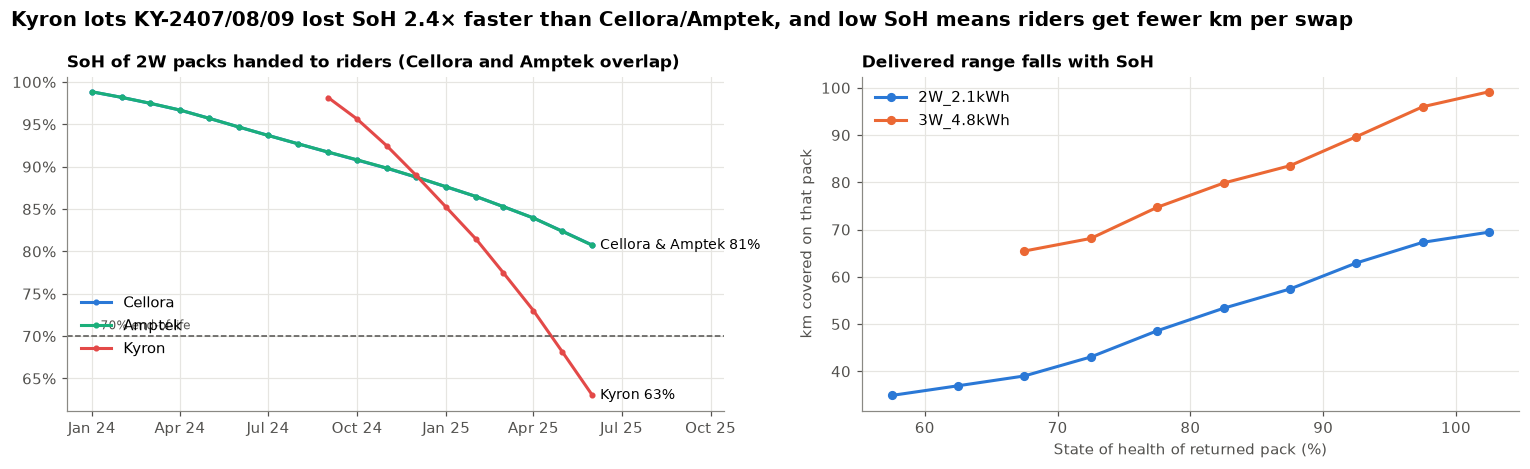

At the same SoH band a Kyron pack delivers 11% fewer km; riders return every supplier's packs at the same ~9% charge, so this is capacity, not behaviour


,supplier,pack,km,soh_in,swaps
0,Amptek,2W_2.1kWh,60.90,89.70,662862
1,Cellora,2W_2.1kWh,60.90,89.70,1832129
2,Kyron,2W_2.1kWh,48.60,80.70,706407
3,Amptek,3W_4.8kWh,90.30,93.00,79047
4,Cellora,3W_4.8kWh,90.30,93.00,196162
5,Kyron,3W_4.8kWh,87.80,90.50,95584


In [29]:
sup_m = q('''SELECT DATE_TRUNC('month', ts) m, sup_out supplier, AVG(soh_out) soh, COUNT(*) n FROM sw WHERE done=1 AND pack_in LIKE '2W%' GROUP BY ALL ORDER BY 1''')
rng = q('''SELECT pack_in pack, FLOOR(soh_in/5)*5 soh_band, AVG(km) km, COUNT(*) n FROM sw WHERE done=1 AND km IS NOT NULL GROUP BY ALL HAVING COUNT(*)>500 ORDER BY 1,2''')
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
ax = axes[0]; scol = {"Cellora": BLUE, "Amptek": AQUA, "Kyron": RED}
for s in ["Cellora", "Amptek", "Kyron"]:
    d = sup_m[sup_m.supplier == s]; ax.plot(pd.to_datetime(d.m), d.soh, color=scol[s], marker="o", ms=3, label=s)
    if s != "Amptek": ax.annotate(("Cellora & Amptek" if s == "Cellora" else s) + f" {d.soh.iloc[-1]:.0f}%", (pd.to_datetime(d.m.iloc[-1]), d.soh.iloc[-1]), xytext=(5, 0), textcoords="offset points", fontsize=9, va="center")
ax.axhline(70, color=INK2, ls="--", lw=1); ax.text(pd.Timestamp("2024-01-10"), 70.8, "70% end-of-life", fontsize=8, color=INK2)
ax.set_title("SoH of 2W packs handed to riders (Cellora and Amptek overlap)", fontsize=11); pct_axis(ax); date_axis(ax); ax.legend(loc="lower left", bbox_to_anchor=(0, 0.12)); ax.set_xlim(right=pd.Timestamp("2025-10-15"))
ax = axes[1]
for p, c in [("2W_2.1kWh", BLUE), ("3W_4.8kWh", ORANGE)]:
    d = rng[rng.pack == p]; ax.plot(d.soh_band + 2.5, d.km, color=c, marker="o", ms=5, label=p)
ax.set_xlabel("State of health of returned pack (%)"); ax.set_ylabel("km covered on that pack"); ax.set_title("Delivered range falls with SoH", fontsize=11); ax.legend()
fig.suptitle("Kyron lots KY-2407/08/09 lost SoH 2.4× faster than Cellora/Amptek, and low SoH means riders get fewer km per swap", x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout(); save(fig, "f08_battery_health")
rs = q('''SELECT sup_in supplier, pack_in pack, AVG(km) km, AVG(soh_in) soh_in, COUNT(*) swaps FROM sw WHERE done=1 AND km IS NOT NULL GROUP BY ALL ORDER BY 2,1''')
keep("km_kyron_2w", rs.query("supplier=='Kyron' and pack=='2W_2.1kWh'").km.iloc[0]); keep("km_cellora_2w", rs.query("supplier=='Cellora' and pack=='2W_2.1kWh'").km.iloc[0])
w2 = wear[wear.pack_type=="2W_2.1kWh"].set_index("supplier")
keep("wear_kyron_2w", w2.loc["Kyron","wear_inr_per_swap"]); keep("wear_cellora_2w", w2.loc["Cellora","wear_inr_per_swap"])
# Same SoH reading, same km? Kyron's SoH figure overstates usable capacity
kb = q('''SELECT FLOOR(soh_in/10)*10 band, sup_in s, AVG(km) km FROM sw WHERE done=1 AND pack_in LIKE '2W%' AND km IS NOT NULL
          GROUP BY ALL HAVING COUNT(*) > 2000''').pivot(index="band", columns="s", values="km").dropna()
keep("kyron_km_gap_same_soh_pct", (100 * (1 - kb["Kyron"] / kb[["Cellora", "Amptek"]].mean(axis=1))).mean())
print(f"At the same SoH band a Kyron pack delivers {METRICS['kyron_km_gap_same_soh_pct']:.0f}% fewer km; riders return every supplier's packs at the same ~9% charge, so this is capacity, not behaviour")
rs.round(1)

In [30]:
# Swap frequency: riders on degraded packs come back sooner (more swaps for the same distance)
freq = q('''WITH x AS (SELECT rider_id, ts, soh_in, sup_in, LAG(ts) OVER (PARTITION BY rider_id ORDER BY ts) prev FROM sw WHERE done=1 AND pack_in LIKE '2W%')
            SELECT CASE WHEN soh_in>=85 THEN '85%+' WHEN soh_in>=75 THEN '75–85%' ELSE '<75%' END soh_band, AVG(EPOCH(ts-prev)/3600) FILTER (WHERE EPOCH(ts-prev) < 86400*3) hours_between_swaps, COUNT(*) swaps
            FROM x GROUP BY 1 ORDER BY 1''')
kt = q("SELECT DATE_TRUNC('quarter', created_ts) qtr, SUM((category_clean='battery_range')::INT) battery_tickets, COUNT(*) all_tickets FROM tk GROUP BY 1 ORDER BY 1")
display(freq.round(2)); kt

,soh_band,hours_between_swaps,swaps
0,75–85%,21.77,784777
1,85%+,22.58,2191242
2,<75%,20.84,238392


,qtr,battery_tickets,all_tickets
0,2024-01-01,308.00,2157
1,2024-04-01,726.00,5007
2,2024-07-01,"1,127.00",4088
3,2024-10-01,"3,066.00",7415
4,2025-01-01,"4,690.00",9811
5,2025-04-01,"6,167.00",15436


### ✅ Finding: Q4. Three Kyron lots stand out, not Kyron as a supplier
- Cellora and Amptek packs are indistinguishable (~32 SoH-points lost per 1,000 swaps). **Kyron lots KY-2407/08/09 lost 75 points per 1,000 swaps (2.4×)**. Kyron's later 3W lots (KY-2410 to 2418) lose **33**, the same as Cellora, so this is a lot defect. BMS firmware makes no difference.
- **Not heat or usage:** the bad packs were concentrated in the hot cities, yet their SoH is identical in all six cities, and riders return every supplier's packs at the same ~9% charge.
- **Range:** delivered km falls steadily with SoH (2W: ~67 km at 95% SoH → ~37 km at 60%). Bad-lot 2W packs averaged **48.6 km vs 60.9 km** per swap, and even at the *same* SoH reading they deliver **11% fewer km**, so their SoH figure overstates usable capacity.
- **Retirement:** all 1,438 retired packs are Kyron, retired after 7–9 months (₹44.3M of 2W packs at purchase cost; the premature part of that cost is ≈₹28.7M). But the retirement exists only in the asset register: the same packs were issued **33,761 more times**, and by June 2025 **22%** of swaps handed riders a pack below the 70% end-of-life line.
- **Riders feel it:** battery/range tickets (incl. mislabelled 'other' tickets) rose from 308 per quarter (Q1-2024) to **6,167 (Q2-2025)**.

## 10. Core Question 5: Pricing and Partner Economics
Three interventions happened in the window: the **base-price increase (1 Jul 2024: 2W ₹60→65, 3W ₹100→110)**, the **peak/off-peak pilot in Bengaluru & Pune (from 1 Oct 2024; peak = 12–14h & 19–23h at +₹15–17, off-peak = 23–6h & 14–17h at −₹8)** and **ZipDrop's contract amendment (1 Nov 2024: discount 12% → 28%, peak surcharge not billable)**.

In [31]:
lp = q('''SELECT vc, list_price_inr, MIN(ts)::DATE first_seen, MAX(ts)::DATE last_seen, COUNT(*) swaps FROM sw WHERE tariff_code='STD' AND done=1 GROUP BY ALL ORDER BY 1,3''')
display(lp)
pk = q('''SELECT tariff_code, LIST(DISTINCT HOUR(ts) ORDER BY HOUR(ts)) hrs, AVG(list_price_inr) avg_list, AVG(rev) avg_charged FROM sw
          WHERE tariff_code IN ('PEAK','OFFPEAK') AND partner_id IS NULL GROUP BY 1''')
pk

,vc,list_price_inr,first_seen,last_seen,swaps
0,2W,60.00,2024-01-01,2024-06-30,221495
1,2W,65.00,2024-07-01,2025-06-30,743222
2,3W,100.00,2024-01-01,2024-06-30,13464
3,3W,110.00,2024-07-01,2025-06-30,41585


,tariff_code,hrs,avg_list,avg_charged
0,OFFPEAK,"[0, 1, 2, 3, 4, 5, 14, 15, 16, 18, 19, 20, 21,...",67.61,56.94
1,PEAK,"[12, 13, 19, 20, 21, 22]",67.64,78.77


In [32]:
# Difference-in-differences on independent riders (the only ones exposed to pilot prices): pilot cities vs control, pre (Jul–Sep 2024) vs post (Oct 2024–Mar 2025).
# Summer months excluded so the heat-driven failure spike (which hits control cities harder) does not contaminate the comparison.
PEAKH = "(HOUR(ts) IN (12,13,19,20,21,22))"
did = q(f'''SELECT (city IN ('Bengaluru','Pune')) pilot, (ts >= '2024-10-01') post, (partner_id IS NULL) independent, COUNT(*) attempts,
            100*AVG({PEAKH}::INT) peak_share, 100*AVG(fail) fail_rate, AVG(rev) FILTER (WHERE done=1) rev_per_swap
            FROM sw WHERE ts >= '2024-07-01' AND ts < '2025-04-01' GROUP BY ALL ORDER BY 3,1,2''')
display(did.round(2))
def did_est(df, col):
    g = df.set_index(["pilot", "post"])[col]; return (g[(True, True)] - g[(True, False)]) - (g[(False, True)] - g[(False, False)])
res = {}
for seg, d in did.groupby("independent"):
    res["Independent riders" if seg else "Fleet-partner riders"] = {c: did_est(d, c) for c in ["peak_share", "fail_rate", "rev_per_swap"]}
res = pd.DataFrame(res).T; display(res.round(2))
keep("did_peak_share_indep", res.loc["Independent riders", "peak_share"]); keep("did_fail_indep", res.loc["Independent riders", "fail_rate"])
keep("did_rev_indep", res.loc["Independent riders", "rev_per_swap"]); keep("did_peak_share_partner", res.loc["Fleet-partner riders", "peak_share"])
# Regression version with station & month fixed effects, SEs clustered by station
sd = q(f'''SELECT station_id, city, DATE_TRUNC('month', ts) m, (city IN ('Bengaluru','Pune'))::INT pilot, (ts >= '2024-10-01')::INT post,
           100*AVG({PEAKH}::INT) peak_share, AVG(rev) FILTER (WHERE done=1) arps, COUNT(*) n
           FROM sw WHERE partner_id IS NULL AND ts >= '2024-07-01' AND ts < '2025-04-01' GROUP BY ALL''')
sd["m"] = sd.m.astype(str)
for y in ["peak_share", "arps"]:
    fit = smf.wls(f"{y} ~ pilot:post + C(station_id) + C(m)", data=sd, weights=sd.n).fit(cov_type="cluster", cov_kwds={"groups": pd.factorize(sd.station_id)[0]})
    print(f"DiD regression {y}: effect = {fit.params['pilot:post']:.2f} (95% CI {fit.conf_int().loc['pilot:post',0]:.2f} to {fit.conf_int().loc['pilot:post',1]:.2f}), p = {fit.pvalues['pilot:post']:.3g}")
    keep(f"did_reg_{y}", fit.params["pilot:post"]); keep(f"did_reg_{y}_p", fit.pvalues["pilot:post"])
# Did riders react by swapping less? Rider-month panel (independents active ≥3 months), rider + month fixed effects, SEs clustered by rider
rm = q('''SELECT rider_id, DATE_TRUNC('month', ts)::VARCHAR m, MAX((city IN ('Bengaluru','Pune'))::INT) pilot, (MIN(ts) >= '2024-10-01')::INT post,
          COUNT(*) FILTER (WHERE done=1) swaps, SUM(rev) revenue FROM sw WHERE partner_id IS NULL AND ts >= '2024-07-01' AND ts < '2025-04-01' GROUP BY rider_id, DATE_TRUNC('month', ts)''')
rm = rm[rm.groupby("rider_id").m.transform("count") >= 3].copy(); rm["tr"] = rm.pilot * rm.post
for y in ["swaps", "revenue"]:
    d = rm.assign(y_dm=rm[y] - rm.groupby("rider_id")[y].transform("mean"), tr_dm=rm.tr - rm.groupby("rider_id").tr.transform("mean"))
    f = smf.ols("y_dm ~ tr_dm + C(m)", data=d).fit(cov_type="cluster", cov_kwds={"groups": pd.factorize(d.rider_id)[0]})
    base = rm[(rm.pilot == 1) & (rm.post == 0)][y].mean()
    keep(f"did_{y}_per_rider_month", f.params["tr_dm"]); keep(f"did_{y}_per_rider_pct", 100 * f.params["tr_dm"] / base)
    print(f"DiD on {y} per rider-month: {f.params['tr_dm']:.2f} ({100*f.params['tr_dm']/base:+.1f}%), 95% CI {f.conf_int().loc['tr_dm',0]:.2f} to {f.conf_int().loc['tr_dm',1]:.2f}")
pre_arps = did[(did.independent) & (did.pilot) & (~did.post)].rev_per_swap.iloc[0]
keep("did_rev_per_swap_pct", 100 * METRICS["did_rev_indep"] / pre_arps)
print(f"Revenue per swap +{METRICS['did_rev_per_swap_pct']:.1f}%, but revenue per rider only +{METRICS['did_revenue_per_rider_pct']:.1f}%: some swaps left the network")

,pilot,post,independent,attempts,peak_share,fail_rate,rev_per_swap
0,False,False,False,212818,54.64,4.08,63.73
1,False,True,False,683479,55.63,4.02,60.96
2,True,False,False,126701,57.04,4.00,63.28
3,True,True,False,351638,54.91,4.05,64.64
4,False,False,True,114645,61.76,3.62,67.41
5,False,True,True,350436,61.68,3.61,67.36
6,True,False,True,62558,61.95,3.64,67.45
7,True,True,True,177672,59.32,3.69,75.34


,peak_share,fail_rate,rev_per_swap
Fleet-partner riders,-3.13,0.11,4.13
Independent riders,-2.55,0.05,7.93


DiD regression peak_share: effect = -2.61 (95% CI -3.20 to -2.02), p = 2.54e-18
DiD regression arps: effect = 7.98 (95% CI 7.68 to 8.29), p = 0


DiD on swaps per rider-month: -0.98 (-4.6%), 95% CI -1.36 to -0.61
DiD on revenue per rider-month: 115.40 (+7.9%), 95% CI 89.73 to 141.06
Revenue per swap +11.8%, but revenue per rider only +7.9%: some swaps left the network


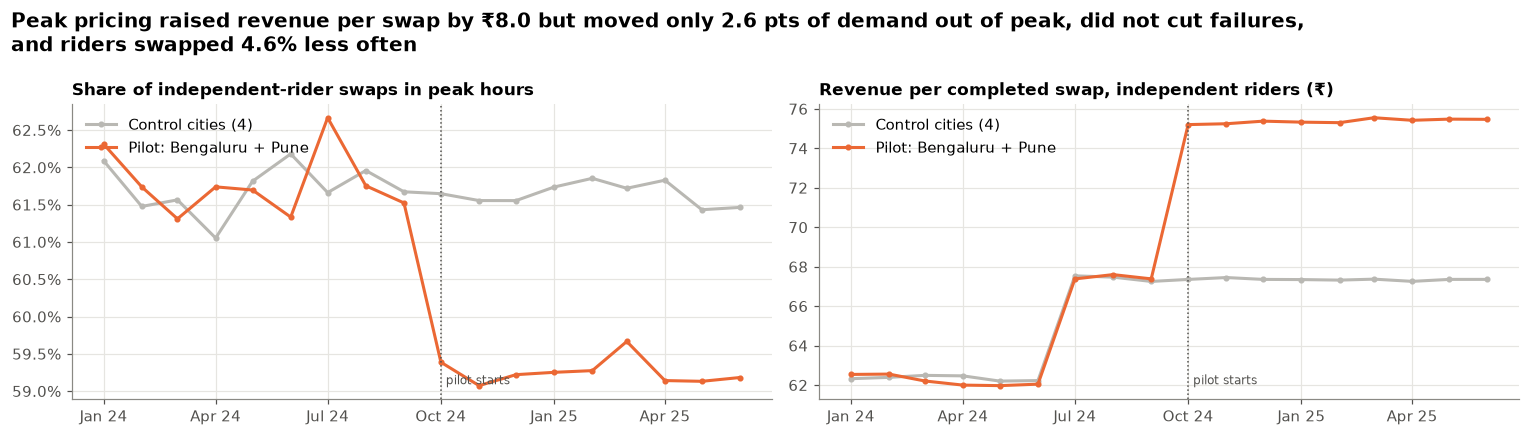

In [33]:
pm = q(f'''SELECT DATE_TRUNC('month', ts) m, (city IN ('Bengaluru','Pune')) pilot, 100*AVG({PEAKH}::INT) peak_share, AVG(rev) FILTER (WHERE done=1) arps
           FROM sw WHERE partner_id IS NULL GROUP BY ALL ORDER BY 1''')
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, ttl, fmt in [(axes[0], "peak_share", "Share of independent-rider swaps in peak hours", "pct"), (axes[1], "arps", "Revenue per completed swap, independent riders (₹)", "inr")]:
    for p, c, lab in [(False, GREY, "Control cities (4)"), (True, ORANGE, "Pilot: Bengaluru + Pune")]:
        d = pm[pm.pilot == p]; ax.plot(pd.to_datetime(d.m), d[col], color=c, marker="o", ms=3, label=lab)
    ax.axvline(pd.Timestamp("2024-10-01"), color=INK2, ls=":", lw=1); ax.text(pd.Timestamp("2024-10-05"), ax.get_ylim()[0] + 0.05*(ax.get_ylim()[1]-ax.get_ylim()[0]), "pilot starts", fontsize=8, color=INK2)
    ax.set_title(ttl, fontsize=11); ax.legend(loc="upper left"); date_axis(ax)
    if fmt == "pct": pct_axis(ax, dec=1)
fig.suptitle(f"Peak pricing raised revenue per swap by ₹{METRICS['did_reg_arps']:.1f} but moved only {abs(METRICS['did_reg_peak_share']):.1f} pts of demand out of peak, did not cut failures,\nand riders swapped {abs(METRICS['did_swaps_per_rider_pct']):.1f}% less often", x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout(); save(fig, "f09_pricing_pilot")

,partner,segment,swaps,rev_per_swap,cm_per_swap,cm_total_m,avg_discount
0,Independent,independent,581013,70.10,-9.73,-5.65,0.00
1,ZipDrop,quick_commerce,262396,48.64,-31.05,-8.15,18.91
2,FeastFly,food_delivery,245889,63.98,-15.58,-3.83,6.74
3,ParcelNest,ecom_logistics,137592,57.53,-22.53,-3.10,10.11
4,Swiggle Go,food_delivery,111004,60.31,-19.56,-2.17,7.45
5,CargoTuk,cargo_3w,62042,101.38,-27.93,-1.73,8.80
6,QuickCart,quick_commerce,58755,64.26,-14.80,-0.87,6.03
7,RideMitra,bike_taxi,58741,64.09,-15.92,-0.94,4.03
8,DabbaXpress,food_delivery,44433,65.46,-13.77,-0.61,5.38
9,MetroMove,ecom_logistics,40313,59.59,-20.78,-0.84,8.09


,period,swaps,discount,rev_per_swap,cm_per_swap
0,before (Jan–Oct 2024),212968,7.84,57.48,-19.68
1,after (Nov 2024–Jun 2025),336422,18.92,48.64,-31.56


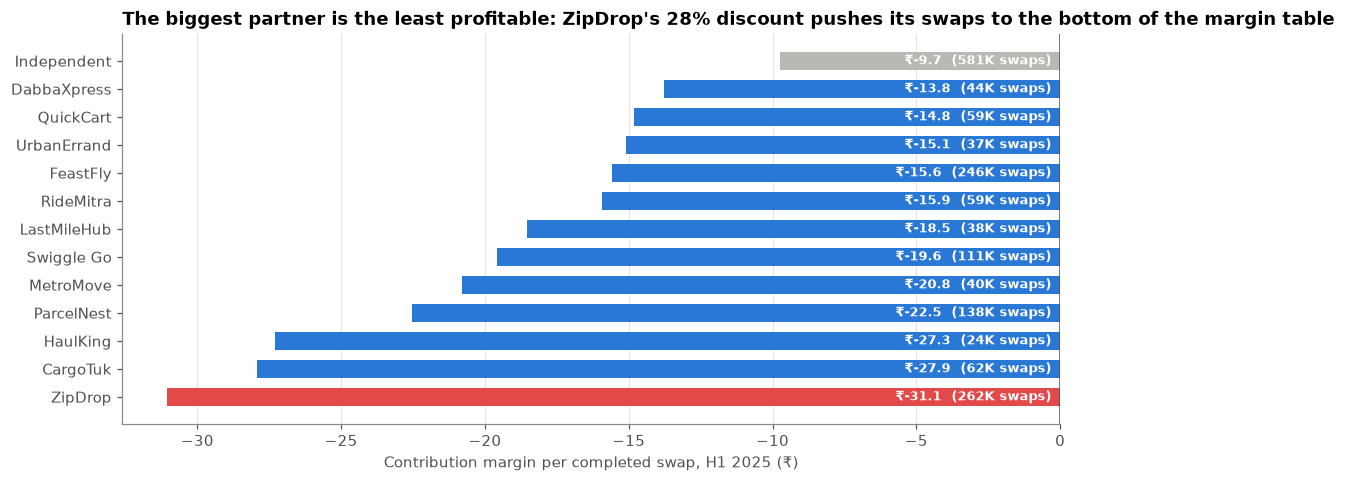

Before site costs: independents +2.1/swap, ZipDrop -19.9/swap; 12 of 12 partners negative. ZipDrop share of swaps 15.1% before the amendment vs 15.5% after: the deeper discount bought no volume


In [34]:
# Partner economics: volume vs margin per swap, and ZipDrop before/after amendment
pe = q('''SELECT COALESCE(p.partner_name, 'Independent') partner, COALESCE(p.partner_segment, 'independent') segment, COUNT(*) swaps, AVG(rev) rev_per_swap, AVG(cm) cm_per_swap, SUM(cm)/1e6 cm_total_m,
          AVG(discount_inr) avg_discount FROM swc LEFT JOIN raw_fleet_partners p USING(partner_id) WHERE ts >= '2025-01-01' GROUP BY ALL ORDER BY swaps DESC''')
display(pe.round(2))
zd = q('''SELECT CASE WHEN ts < '2024-11-01' THEN 'before (Jan–Oct 2024)' ELSE 'after (Nov 2024–Jun 2025)' END period, COUNT(*) swaps, AVG(discount_inr) discount, AVG(rev) rev_per_swap, AVG(cm) cm_per_swap
          FROM swc WHERE partner_id='FP-03' GROUP BY 1 ORDER BY 1 DESC''')
display(zd.round(2))
fig, ax = plt.subplots(figsize=(11, 4.6)); d = pe.sort_values("cm_per_swap")
cols = [RED if p == "ZipDrop" else (GREY if p == "Independent" else BLUE) for p in d.partner]
ax.barh(d.partner, d.cm_per_swap, color=cols, height=0.65); ax.axvline(0, color=INK2, lw=1)
for i, (v, s) in enumerate(zip(d.cm_per_swap, d.swaps)): ax.text(-0.3, i, f"₹{v:.1f}  ({s/1e3:.0f}K swaps)", va="center", ha="right", fontsize=8.5, color="white", fontweight="bold")
ax.set_xlabel("Contribution margin per completed swap, H1 2025 (₹)"); ax.grid(axis="y", visible=False)
ax.set_title("The biggest partner is the least profitable: ZipDrop's 28% discount pushes its swaps to the bottom of the margin table")
save(fig, "f10_partner_margin")
z = zd.set_index("period")
keep("zipdrop_rev_before", z.iloc[0].rev_per_swap); keep("zipdrop_rev_after", z.iloc[1].rev_per_swap); keep("zipdrop_cm_before", z.iloc[0].cm_per_swap); keep("zipdrop_cm_after", z.iloc[1].cm_per_swap)
keep("zipdrop_share_h1_25", 100 * pe.query("partner=='ZipDrop'").swaps.iloc[0] / pe.swaps.sum())
keep("zipdrop_cm_h1_25", pe.query("partner=='ZipDrop'").cm_per_swap.iloc[0]); keep("best_partner_cm", pe[pe.partner!="Independent"].cm_per_swap.max())
keep("best_partner", pe[pe.partner!="Independent"].sort_values("cm_per_swap").partner.iloc[-1]); keep("indep_cm_h1_25", pe.query("partner=='Independent'").cm_per_swap.iloc[0])
# For a single-partner decision, site rent is sunk: does each swap at least cover its own energy + battery wear?
vm = q('''SELECT COALESCE(p.partner_name,'Independent') partner, AVG(rev - energy_cost - wear_cost) variable_margin FROM swc LEFT JOIN raw_fleet_partners p USING(partner_id)
          WHERE ts >= '2025-01-01' GROUP BY 1''').set_index("partner").variable_margin
keep("zipdrop_variable_margin", vm["ZipDrop"]); keep("indep_variable_margin", vm["Independent"]); keep("partners_negative_variable", int((vm.drop("Independent") < 0).sum()))
zs = q('''SELECT (ts >= '2024-11-01') after_deal, 100*SUM(done) FILTER (WHERE partner_id='FP-03')/SUM(done) zd_share FROM sw GROUP BY 1''').set_index("after_deal").zd_share
keep("zipdrop_share_before", zs.loc[False]); keep("zipdrop_share_after", zs.loc[True])
print(f"Before site costs: independents {vm['Independent']:+.1f}/swap, ZipDrop {vm['ZipDrop']:+.1f}/swap; {METRICS['partners_negative_variable']} of 12 partners negative. "
      f"ZipDrop share of swaps {zs.loc[False]:.1f}% before the amendment vs {zs.loc[True]:.1f}% after: the deeper discount bought no volume")

### ✅ Finding: Q5. Pricing and partner terms hit segments very differently
- **Base price rise (1 Jul 2024, 2W ₹60→65, 3W ₹100→110):** revenue per swap rose ~₹5 and volume growth did not slow, so demand is not price-sensitive at this level.
- **Peak/off-peak pilot (Bengaluru & Pune from Oct 2024):** difference-in-differences vs the four control cities, with station and month fixed effects, gives **+₹8.0 revenue per swap** for independent riders (95% CI 7.7–8.3) but only a **−2.6 pt** shift of swaps out of peak hours and **no change in failure rate** (+0.05 pts). Riders did react in another way: on a rider-month panel with rider and month fixed effects they swapped **4.6% less often**, so revenue per rider rose **7.9%**, not the 11.8% implied per swap. **The pilot works as a revenue lever, not a congestion lever.** It also misses the partners exempt from the surcharge (ZipDrop, Swiggle Go).
- **ZipDrop amendment (Nov 2024, discount 12%→28%):** revenue per ZipDrop swap fell **₹57.5 → ₹48.6** and CM per swap fell **−₹19.7 → −₹31.6**. ZipDrop is **15% of volume** and the **least profitable customer on the network**, losing ₹19.9 per swap even before site costs. The deeper discount bought no extra volume (share 15.1% before, 15.5% after). The best partner (DabbaXpress) earns −₹13.8 and independents −₹9.7. The extra discount costs ≈**₹5.7M a year**.
- 3W cargo partners (CargoTuk, HaulKing) are also margin-negative despite the ₹110 price, because 3W packs carry ₹77–81 of wear per swap.

## 11. Core Question 6: Root Cause of New-Rider Churn
**Definition.** New rider = signed up on or after 1 Jan 2024 (their first swap is within ~1 day of signup). **Early churn** = the rider's last swap falls within 30 days of their first swap. We only include riders whose first swap was before 1 May 2025, so at least 60 days are observable (no right-censoring). **Features** describe what the rider *experienced in their first 14 days*, before the churn outcome, so they can precede it.

In [35]:
con.execute('''CREATE OR REPLACE TABLE ra AS SELECT rider_id, MIN(ts) first_ts, MAX(ts) last_ts, COUNT(*) n_all FROM sw GROUP BY 1''')
con.execute('''
CREATE OR REPLACE TABLE rf AS
WITH base AS (SELECT r.*, a.first_ts, a.last_ts, (a.last_ts < a.first_ts + INTERVAL 30 DAY)::INT churn30 FROM riders r JOIN ra a USING(rider_id)
              WHERE r.signup_date >= '2024-01-01' AND a.first_ts < '2025-05-01'),
w AS (SELECT sw.*, st.competitor_within_1_5km_since comp_since FROM sw JOIN base b USING(rider_id) JOIN stations st USING(station_id) WHERE sw.ts < b.first_ts + INTERVAL 14 DAY),
agg AS (SELECT rider_id, COUNT(*) n14, SUM(fail) fails14, SUM((event_type='failed_no_charged_battery')::INT) nobatt14, SUM((event_type='abandoned_queue')::INT) aband14,
        AVG(soh_out) soh_out14, AVG((sup_out='Kyron')::INT) kyron14, AVG(km) km14, MODE(gen) gen, MODE(city) city,
        MAX((comp_since IS NOT NULL AND comp_since <= ts)::INT) comp_near, AVG((gen='Gen1')::INT) gen1_share FROM w GROUP BY 1),
tix AS (SELECT t.rider_id, COUNT(*) tickets14 FROM tk t JOIN base b USING(rider_id) WHERE t.created_ts < b.first_ts + INTERVAL 14 DAY GROUP BY 1)
SELECT b.rider_id, b.churn30, b.first_ts, b.vehicle_class, b.plan_type, b.signup_channel, b.partner_id, b.kyc_verified, b.home_city, DATE_TRUNC('quarter', b.first_ts) cohort,
       (MONTH(b.first_ts) IN (4,5,6))::INT summer_start, a.*, COALESCE(t.tickets14,0) tickets14
FROM base b JOIN agg a USING(rider_id) LEFT JOIN tix t USING(rider_id)''')
rf = q("SELECT * FROM rf")
rf["fail2plus"] = (rf.fails14 >= 2).astype(int); rf["low_soh_pack"] = (rf.soh_out14 < 85).astype(int); rf["kyron_heavy"] = (rf.kyron14 >= 0.5).astype(int)
rf["ticket14"] = (rf.tickets14 > 0).astype(int); rf["independent"] = rf.partner_id.isna().astype(int); rf["is_3w"] = (rf.vehicle_class == "3W").astype(int)
rf["gen1_home"] = (rf.gen1_share >= 0.5).astype(int)
base_churn = rf.churn30.mean() * 100
keep("new_riders_analysed", len(rf)); keep("churn30_overall", base_churn)
print(f"{len(rf):,} new riders analysed; 30-day churn = {base_churn:.2f}%")

13,797 new riders analysed; 30-day churn = 9.93%


In [36]:
# Univariate lift: churn rate when the factor is present vs absent
FACTORS = {"fail2plus": "2+ failed swaps in first 14 days", "low_soh_pack": "Given packs averaging <85% SoH", "summer_start": "Started in summer (Apr–Jun)",
           "gen1_home": "Mostly used Gen1 stations", "kyron_heavy": "≥50% of packs were Kyron", "comp_near": "Competitor opened within 1.5 km",
           "ticket14": "Raised a support ticket", "is_3w": "3W rider", "independent": "Independent (not fleet)"}
rows = []
for f, lab in FACTORS.items():
    y1 = rf.loc[rf[f] == 1, "churn30"]; y0 = rf.loc[rf[f] == 0, "churn30"]
    ct = pd.crosstab(rf[f], rf.churn30); p = stats.chi2_contingency(ct)[1]
    rows.append(dict(factor=lab, key=f, exposed_pct=100*rf[f].mean(), churn_if_yes=100*y1.mean(), churn_if_no=100*y0.mean(), lift=y1.mean()/y0.mean(), p_value=p))
lift = pd.DataFrame(rows).sort_values("lift", ascending=False)
lift["excess_churners"] = (lift.churn_if_yes - lift.churn_if_no) / 100 * lift.exposed_pct / 100 * len(rf)
lift.round(3)

,factor,key,exposed_pct,churn_if_yes,churn_if_no,lift,p_value,excess_churners
0,2+ failed swaps in first 14 days,fail2plus,16.28,14.96,8.95,1.67,0.00,134.95
2,Started in summer (Apr–Jun),summer_start,23.21,13.62,8.81,1.54,0.00,153.73
1,Given packs averaging <85% SoH,low_soh_pack,12.73,12.86,9.50,1.35,0.00,59.06
4,≥50% of packs were Kyron,kyron_heavy,8.81,11.61,9.77,1.19,0.05,22.32
5,Competitor opened within 1.5 km,comp_near,4.64,11.25,9.87,1.14,0.28,8.86
6,Raised a support ticket,ticket14,13.42,10.85,9.79,1.11,0.17,19.75
7,3W rider,is_3w,14.48,10.81,9.78,1.10,0.17,20.59
3,Mostly used Gen1 stations,gen1_home,51.27,10.30,9.53,1.08,0.14,54.53
8,Independent (not fleet),independent,38.69,9.12,10.44,0.87,0.01,-70.21


,odds_ratio,ci_low,ci_high,p
C(plan_type)[T.pay_as_you_go],0.92,0.69,1.23,0.59
C(plan_type)[T.prepaid_pack],1.06,0.78,1.45,0.69
C(home_city)[T.Delhi NCR],1.15,0.95,1.39,0.17
C(home_city)[T.Hyderabad],1.11,0.91,1.36,0.29
C(home_city)[T.Jaipur],1.27,1.03,1.57,0.03
C(home_city)[T.Mumbai],0.92,0.74,1.14,0.46
C(home_city)[T.Pune],1.13,0.93,1.38,0.23
C(signup_channel)[T.field_agent],1.08,0.83,1.42,0.56
C(signup_channel)[T.partner_onboarding],1.12,0.82,1.54,0.46
C(signup_channel)[T.referral],1.06,0.86,1.31,0.57


Pseudo-R² 0.015, n = 13,797


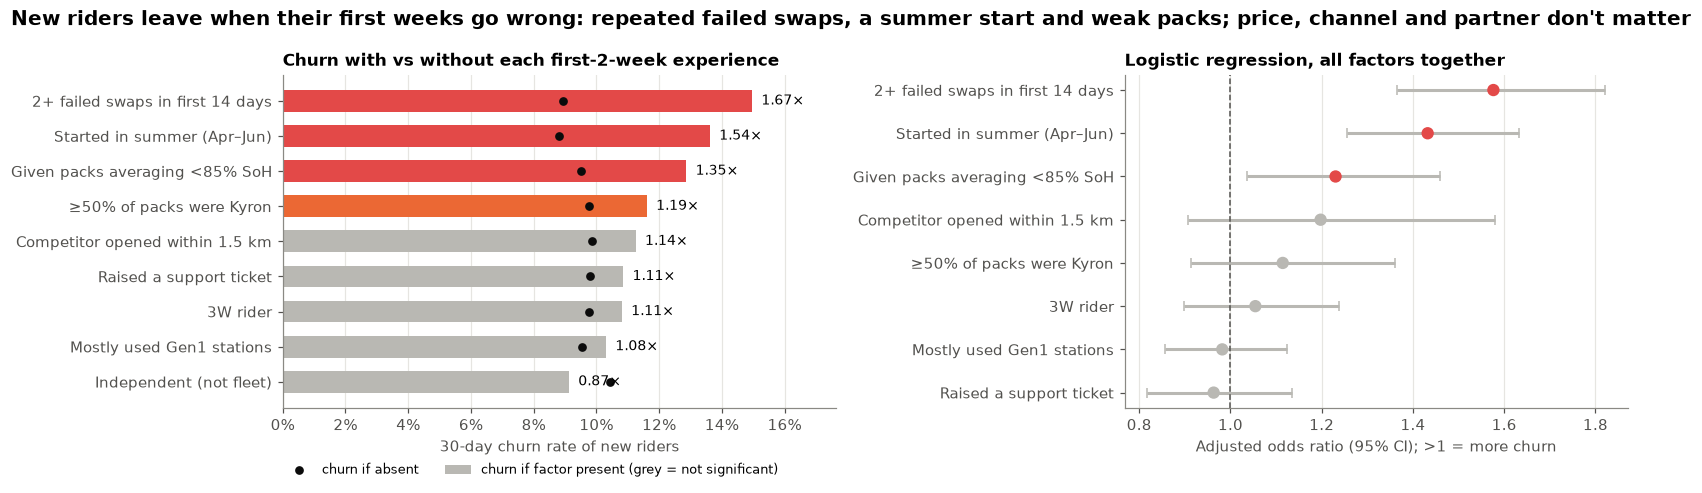

In [37]:
# Multivariate logistic regression: which factors still matter when considered together?
form = "churn30 ~ fail2plus + low_soh_pack + summer_start + gen1_home + kyron_heavy + comp_near + ticket14 + is_3w + C(plan_type) + C(home_city) + C(signup_channel)"
logit = smf.logit(form, data=rf).fit(disp=False)
orr = pd.DataFrame({"odds_ratio": np.exp(logit.params), "ci_low": np.exp(logit.conf_int()[0]), "ci_high": np.exp(logit.conf_int()[1]), "p": logit.pvalues}).drop("Intercept")
display(orr.round(3))
print(f"Pseudo-R² {logit.prsquared:.3f}, n = {int(logit.nobs):,}")
core = orr.loc[[k for k in FACTORS if k in orr.index and k != "independent"]].copy()
core["label"] = [FACTORS[k] for k in core.index]; core = core.sort_values("odds_ratio")
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={"width_ratios": [1.1, 1]})
ax = axes[0]; L = lift.sort_values("lift")
ax.barh(L.factor, L.churn_if_yes, color=[(RED if lf >= 1.3 else ORANGE) if pv < 0.05 and lf > 1 else GREY for lf, pv in zip(L.lift, L.p_value)], height=0.62, label="churn if factor present (grey = not significant)")
ax.scatter(L.churn_if_no, L.factor, color=INK, zorder=3, s=22, label="churn if absent")
for i, (v, lf) in enumerate(zip(L.churn_if_yes, L.lift)): ax.text(v + 0.3, i, f"{lf:.2f}×", va="center", fontsize=9)
pct_axis(ax, "x"); ax.set_xlabel("30-day churn rate of new riders"); ax.set_xlim(0, L.churn_if_yes.max()*1.18); ax.set_title("Churn with vs without each first-2-week experience", fontsize=11)
ax.legend(loc="upper center", bbox_to_anchor=(0.45, -0.13), ncol=2, fontsize=8.5); ax.grid(axis="y", visible=False)
ax = axes[1]
sig = core.p < 0.05
ax.errorbar(core.odds_ratio, core.label, xerr=[core.odds_ratio - core.ci_low, core.ci_high - core.odds_ratio], fmt="none", ecolor=GREY, capsize=3)
ax.scatter(core.odds_ratio, core.label, color=[RED if (s and o > 1.2) else (BLUE if s else GREY) for s, o in zip(sig, core.odds_ratio)], s=50, zorder=3)
ax.axvline(1, color=INK2, lw=1, ls="--"); ax.set_xlabel("Adjusted odds ratio (95% CI); >1 = more churn"); ax.set_title("Logistic regression, all factors together", fontsize=11); ax.grid(axis="y", visible=False)
fig.suptitle("New riders leave when their first weeks go wrong: repeated failed swaps, a summer start and weak packs; price, channel and partner don't matter", x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout(); save(fig, "f11_churn_drivers")
for k in core.index: keep(f"or_{k}", core.loc[k, "odds_ratio"]); keep(f"p_{k}", core.loc[k, "p"])
for _, r in lift.iterrows(): keep(f"churn_yes_{r.key}", r.churn_if_yes); keep(f"churn_no_{r.key}", r.churn_if_no); keep(f"lift_{r.key}", r.lift); keep(f"exposed_{r.key}", r.exposed_pct)

**Robustness: are these odds ratios too high or too low?** Riders who ride more see more failures *and* churn less, which pulls the failure effect down. Adding early activity (log of first-14-day attempts) as a control removes that bias. Activity is partly an outcome itself (a rider who quits on day 5 has few swaps), so the adjusted odds ratios are an **upper bound** and the ones above a **lower bound**. We also test two factors the main model leaves out: competitor promotions and city heat in the rider's first month.

In [38]:
ctx = q('''SELECT rf.rider_id, AVG((c.competitor_promo_active::VARCHAR IN ('true','True','1'))::INT) promo30, AVG(c.max_temp_c) tmax30
           FROM rf JOIN raw_city_daily_context c ON c.city = rf.city AND c.date::DATE BETWEEN rf.first_ts::DATE AND rf.first_ts::DATE + 30 GROUP BY 1''')
rf = rf.merge(ctx, on="rider_id", how="left"); rf["log_n14"] = np.log(rf.n14)
m_adj = smf.logit(form + " + log_n14", data=rf).fit(disp=False)
m_ctx = smf.logit(form + " + log_n14 + promo30 + tmax30", data=rf).fit(disp=False)
KEYS = ["fail2plus", "low_soh_pack", "summer_start"]
adj = pd.DataFrame({"odds_ratio_original": np.exp(logit.params[KEYS]), "odds_ratio_activity_adjusted": np.exp(m_adj.params[KEYS]),
                    "ci_low_adj": np.exp(m_adj.conf_int().loc[KEYS, 0]), "ci_high_adj": np.exp(m_adj.conf_int().loc[KEYS, 1]), "p_adj": m_adj.pvalues[KEYS]})
for k in KEYS: keep(f"or_{k}_adjusted", adj.loc[k, "odds_ratio_activity_adjusted"])
keep("or_promo30", np.exp(m_ctx.params["promo30"])); keep("p_promo30", m_ctx.pvalues["promo30"]); keep("p_tmax30", m_ctx.pvalues["tmax30"])
frate = 100 * rf.fails14 / rf.n14
keep("churn_fail_rate_over20", 100 * rf[frate > 20].churn30.mean()); keep("churn_fail_rate_zero", 100 * rf[frate == 0].churn30.mean())
keep("riders_saved_high", (m_adj.predict(rf) - m_adj.predict(rf.assign(fail2plus=0))).sum())
# Which intake churned worst, and does the model explain it?
rf["pred"] = m_adj.predict(rf)
co = rf.groupby("cohort").agg(riders=("churn30", "size"), churn_pct=("churn30", "mean"), predicted_pct=("pred", "mean"), low_soh_pct=("low_soh_pack", "mean"))
co[["churn_pct", "predicted_pct", "low_soh_pct"]] *= 100; co.index = pd.to_datetime(co.index).to_period("Q").astype(str)
keep("churn_q2_2025", co.loc["2025Q2", "churn_pct"]); keep("churn_q2_2024", co.loc["2024Q2", "churn_pct"]); keep("pred_q2_2025", co.loc["2025Q2", "predicted_pct"])
keep("low_soh_share_q2_2025", co.loc["2025Q2", "low_soh_pct"])
display(adj.round(3))
print(f"Competitor promotions: OR {METRICS['or_promo30']:.2f} (p = {METRICS['p_promo30']:.2f}); city heat beyond the summer flag: p = {METRICS['p_tmax30']:.2f}. Neither is a driver.")
print(f"Riders whose early failure rate exceeded 20% churned at {METRICS['churn_fail_rate_over20']:.1f}% vs {METRICS['churn_fail_rate_zero']:.1f}% with no failures")
co.round(1)

,odds_ratio_original,odds_ratio_activity_adjusted,ci_low_adj,ci_high_adj,p_adj
fail2plus,1.58,2.05,1.77,2.39,0.00
low_soh_pack,1.23,1.46,1.22,1.74,0.00
summer_start,1.43,1.31,1.14,1.50,0.00


Competitor promotions: OR 0.90 (p = 0.63); city heat beyond the summer flag: p = 0.34. Neither is a driver.
Riders whose early failure rate exceeded 20% churned at 23.3% vs 9.1% with no failures


,riders,churn_pct,predicted_pct,low_soh_pct
cohort,,,,
2024Q1,1750,9.30,9.30,0.00
2024Q2,2094,11.90,13.10,0.00
2024Q3,2529,8.10,8.60,0.00
2024Q4,3270,8.80,8.10,0.00
2025Q1,3046,9.10,9.50,29.50
2025Q2,1108,16.80,14.60,77.50


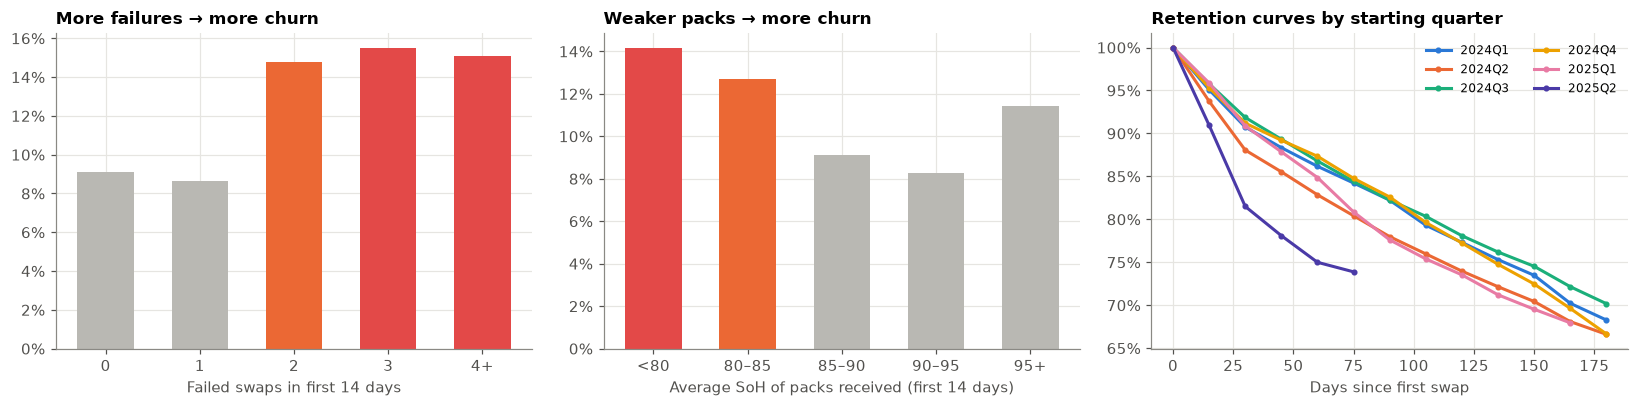

,riders,churn
f,,
0.00,7350,9.13
1.00,4201,8.64
2.00,1497,14.76
3.00,510,15.49
4.00,239,15.06


,riders,churn
b,,
<80,212,14.15
80–85,1546,12.68
85–90,3074,9.14
90–95,5097,8.26
95+,3868,11.43


In [39]:
# Dose-response: more failures → more churn (a causal-style signature)
dr = rf.assign(f=rf.fails14.clip(upper=4)).groupby("f").agg(riders=("churn30", "size"), churn=("churn30", "mean")); dr["churn"] *= 100
dr2 = rf.assign(b=pd.cut(rf.soh_out14, [0, 80, 85, 90, 95, 101], labels=["<80", "80–85", "85–90", "90–95", "95+"])).groupby("b").agg(riders=("churn30", "size"), churn=("churn30", "mean")); dr2["churn"] *= 100
coh = q('''WITH a AS (SELECT r.rider_id, DATE_TRUNC('quarter', ra.first_ts) cohort, ra.first_ts, ra.last_ts FROM riders r JOIN ra USING(rider_id) WHERE r.signup_date >= '2024-01-01')
           SELECT cohort, d, 100*AVG((last_ts >= first_ts + d * INTERVAL 1 DAY)::INT) retained, COUNT(*) n
           FROM a, (SELECT UNNEST(RANGE(0, 181, 15)) d) g WHERE first_ts + d * INTERVAL 1 DAY <= TIMESTAMP '2025-06-30' GROUP BY ALL ORDER BY 1, 2''')
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].bar(dr.index.astype(str), dr.churn, color=[GREY, GREY, ORANGE, RED, RED], width=0.6); axes[0].set_xticklabels(["0", "1", "2", "3", "4+"])
axes[0].set_xlabel("Failed swaps in first 14 days"); axes[0].set_title("More failures → more churn", fontsize=11); pct_axis(axes[0])
axes[1].bar(dr2.index.astype(str), dr2.churn, color=[RED, ORANGE, GREY, GREY, GREY], width=0.6); axes[1].set_xlabel("Average SoH of packs received (first 14 days)"); axes[1].set_title("Weaker packs → more churn", fontsize=11); pct_axis(axes[1])
cc = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, VIOLET]
for i, (c, d) in enumerate(coh.groupby("cohort")):
    lab = pd.Timestamp(c).strftime("%Y") + "Q" + str(pd.Timestamp(c).quarter)
    axes[2].plot(d.d, d.retained, color=cc[i % len(cc)], marker="o", ms=3, label=lab)
axes[2].set_xlabel("Days since first swap"); axes[2].set_title("Retention curves by starting quarter", fontsize=11); pct_axis(axes[2]); axes[2].legend(fontsize=8, ncol=2)
fig.tight_layout(); save(fig, "f12_churn_dose_response")
display(dr.round(2)); display(dr2.round(2))

### ✅ Finding: Q6. Primary vs secondary drivers of new-rider churn
| Tier | Factor | Evidence |
|---|---|---|
| **Primary** | **2+ failed swaps in the first 14 days** | churn 15.0% vs 9.0%; adjusted OR **1.58** (p<0.001), **2.05** once early activity is controlled; riders whose early failure rate exceeded 20% churned at **23.3%**; 16% of new riders exposed |
| **Primary** | **Starting in summer (Apr–Jun)** | churn 13.6% vs 8.8%; OR **1.43** even after controlling for early failures (1.31 with activity), so the whole first month matters, not just the first two weeks |
| **Contributing** | **Weak packs (avg SoH < 85%)** | churn 12.9% vs 9.5%; OR **1.23** (p=0.02), 1.46 with activity; only 2025 riders ever received such packs, so it stays contributing |
| Secondary / not significant | Kyron-heavy packs, nearby competitor, 3W, raising a ticket | 1.1–1.2× raw lift, not significant once failures and pack health are controlled |
| **Not a driver** | Price plan, signup channel, fleet partner, KYC, Gen1 home station, competitor promotions | no significant effect (promotions: OR 0.90, p=0.63). Gen1's effect runs *through* failures (a mediator) |

**Worst intake:** riders who started in April 2025 churned at **16.8%** vs 11.9% a year earlier; the model predicts 14.6%, so these drivers explain most but not all of the jump.

**Interpretation:** a new rider's first experiences decide whether they stay. The same Gen1-in-summer and weak-battery problems behind Q2–Q4 are what push new riders out. Retention is an operations problem, not a marketing or pricing one. (Churn is also noisy: pseudo-R² 0.015. These are the controllable levers, not the whole story.)

## 12. Deep-Dives

### 12.1 Expansion waves: did new stations go where riders needed them?

In [40]:
ew = q('''WITH hot AS (SELECT city, 100*AVG(fail) FILTER (WHERE MONTH(ts) IN (4,5,6) AND YEAR(ts)=2024) summer24_fail, COUNT(*) FILTER (WHERE YEAR(ts)=2024) att24 FROM sw GROUP BY 1)
          SELECT s.city, h.summer24_fail, SUM((s.expansion_wave='Launch')::INT) launch, SUM((s.expansion_wave<>'Launch')::INT) new_stations,
                 SUM((s.expansion_wave='Launch' AND s.charger_generation='Gen1')::INT) gen1_left, 100.0*SUM((s.expansion_wave<>'Launch')::INT)/SUM((s.expansion_wave='Launch')::INT) growth_pct
          FROM stations s JOIN hot h USING(city) GROUP BY ALL ORDER BY 2 DESC''')
display(ew.round(1))
# did Launch Gen1 stations in hot cities improve from summer 2024 to summer 2025 (i.e., did new capacity relieve them)?
imp = q('''SELECT city, gen, 100*AVG(fail) FILTER (WHERE ts BETWEEN '2024-04-01' AND '2024-06-30 23:59:59') summer24, 100*AVG(fail) FILTER (WHERE ts BETWEEN '2025-04-01' AND '2025-06-30 23:59:59') summer25
           FROM sw WHERE wave='Launch' GROUP BY ALL ORDER BY 1,2''')
display(imp.round(2))
keep("gen1_stations_remaining", int(q("SELECT COUNT(*) n FROM stations WHERE charger_generation='Gen1'").n[0]))
keep("gen1_share_attempts", q("SELECT 100*AVG((gen='Gen1')::INT) p FROM sw").p[0])
keep("gen1_share_fails", q("SELECT 100*SUM(fail) FILTER (WHERE gen='Gen1')/SUM(fail) p FROM sw").p[0])
keep("gen1_share_summer_fails", q("SELECT 100*SUM(fail) FILTER (WHERE gen='Gen1')/SUM(fail) p FROM sw WHERE MONTH(ts) IN (4,5,6)").p[0])

,city,summer24_fail,launch,new_stations,gen1_left,growth_pct
0,Jaipur,17.10,10.00,8.00,10.00,80.00
1,Delhi NCR,14.00,18.00,12.00,13.00,66.70
2,Hyderabad,12.30,16.00,10.00,13.00,62.50
3,Pune,6.00,13.00,9.00,4.00,69.20
4,Bengaluru,4.70,20.00,12.00,9.00,60.00
5,Mumbai,4.00,13.00,9.00,2.00,69.20


,city,gen,summer24,summer25
0,Bengaluru,Gen1,4.90,4.79
1,Bengaluru,Gen2,4.44,4.31
2,Delhi NCR,Gen1,16.35,16.64
3,Delhi NCR,Gen2,8.19,8.46
4,Hyderabad,Gen1,13.31,12.88
5,Hyderabad,Gen2,7.53,7.21
6,Jaipur,Gen1,17.08,16.57
7,Mumbai,Gen1,4.22,4.03
8,Mumbai,Gen2,4.00,4.07
9,Pune,Gen1,7.51,7.36


np.float64(65.60440028994158)

### 12.2 Anomalies worth flagging

In [41]:
an = []
an.append(("Test stations STN-TST-01/02", f"{METRICS['test_station_rows']:,} transactions worth ₹{METRICS['test_station_rev_m']:.2f}M, 24 hours a day; the brief says they are small and zero-value. Treat as an internal data-governance issue."))
an.append(("Firmware v3.2.0 window", f"{METRICS['fw_bug_rows']:,} events logged 5h30m early (10 Mar – 14 Apr 2025). Without the fix, peak-hour share looks like it dropped 14 pts in Mar 2025."))
an.append(("Kyron lots KY-2407/08/09", f"All {METRICS['kyron_retired_packs']:,} retired packs are Kyron, retired after {METRICS['retire_months_min']}–{METRICS['retire_months_max']} months (₹{METRICS['writeoff_2w_m']:.1f}M of 2W packs at purchase cost). Kyron's later 3W lots wear normally, so this is a lot defect, not a supplier-wide one."))
an.append(("Retired packs still in service", f"All retirements share one date (15 Jun 2025), yet {METRICS['anom_retired_packs_after']:,} 'retired' packs were issued {METRICS['anom_retired_swaps_after']:,} more times, and {METRICS['eol_share_jun25']:.0f}% of June-2025 swaps issued a pack below 70% SoH. The asset register and the cabinets disagree."))
an.append(("slots_3w field", f"{METRICS['anom_3w_no_slot_pct']:.0f}% of completed 3W swaps happen at stations listed with zero 3W slots, so the field cannot be trusted."))
an.append(("payment_mode", "Every row says partner_invoice, even for pay-as-you-go riders: a billing-export defect that finance should look at."))
an.append(("Gen1 thermal cliff", f"At ≥45°C cabinet temp Gen1 charge time jumps to {METRICS['gen1_charge_min_hot']:.0f} min and stock hits zero in {METRICS['gen1_stockout_hot']:.0f}% of hours."))
pd.DataFrame(an, columns=["anomaly", "detail"])

,anomaly,detail
0,Test stations STN-TST-01/02,"62,031 transactions worth ₹3.93M, 24 hours a d..."
1,Firmware v3.2.0 window,"139,490 events logged 5h30m early (10 Mar – 14..."
2,Kyron lots KY-2407/08/09,"All 1,438 retired packs are Kyron, retired aft..."
3,Retired packs still in service,"All retirements share one date (15 Jun 2025), ..."
4,slots_3w field,57% of completed 3W swaps happen at stations l...
5,payment_mode,"Every row says partner_invoice, even for pay-a..."
6,Gen1 thermal cliff,At ≥45°C cabinet temp Gen1 charge time jumps t...


### 12.3 The budget decision: what does the evidence support?

In [42]:
inr = lambda v: f"{chr(8722) if v < 0 else ''}₹{abs(v):.1f}"
budget = pd.DataFrame([
  ("More stations", "Partly: only as Gen1→Gen3 replacement in Jaipur, Delhi NCR, Hyderabad",
   f"New waves went to easier sites; all {METRICS['gen1_stations_remaining']} Gen1 cabinets remain and cause {METRICS['gen1_share_summer_fails']:.0f}% of summer failures. Gen1 fails 3× Gen3 at every load level, so more Gen1-style sites would not fix the heat problem."),
  ("More batteries", "Yes, but as replacements, not fleet growth",
   f"The {METRICS['writeoff_2w_packs']:,} retired Kyron 2W packs ({METRICS['retired_2w_share_of_fleet']:.0f}% of the 2W fleet, ≈₹{METRICS['writeoff_2w_m']:.0f}M) must be pulled and replaced before next summer. They deliver {METRICS['km_kyron_2w']:.0f} km vs {METRICS['km_cellora_2w']:.0f} km and cost ₹{METRICS['wear_kyron_2w']:.0f}/swap in wear vs ₹{METRICS['wear_cellora_2w']:.0f}. Buy on lot acceptance tests, not supplier name."),
  ("Network-wide peak pricing", "Not as proposed; roll out as a revenue tool only, with partner billing fixed first",
   f"Pilot: +₹{METRICS['did_reg_arps']:.1f} per swap for independents, but riders swapped {abs(METRICS['did_swaps_per_rider_pct']):.1f}% less often, only {abs(METRICS['did_reg_peak_share']):.1f} pts of demand shifted and failures did not fall. It does not relieve congestion, and exempt partners (ZipDrop) dodge it."),
  ("Long-term ZipDrop exclusive", "No",
   f"ZipDrop is ~{METRICS['zipdrop_share_h1_25']:.0f}% of volume but earns {inr(METRICS['zipdrop_cm_h1_25'])}/swap in CM vs {inr(METRICS['best_partner_cm'])} for {METRICS['best_partner']}, and {inr(METRICS['zipdrop_variable_margin'])} even before site costs. The 28% discount bought no extra volume. Locking it in locks in the lowest margin on the network."),
], columns=["proposal", "verdict", "evidence"])
budget.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "pre-wrap"})

proposal,verdict,evidence
More stations,"Partly: only as Gen1→Gen3 replacement in Jaipur, Delhi NCR, Hyderabad","New waves went to easier sites; all 51 Gen1 cabinets remain and cause 66% of summer failures. Gen1 fails 3× Gen3 at every load level, so more Gen1-style sites would not fix the heat problem."
More batteries,"Yes, but as replacements, not fleet growth","The 1,385 retired Kyron 2W packs (25% of the 2W fleet, ≈₹44M) must be pulled and replaced before next summer. They deliver 49 km vs 61 km and cost ₹82/swap in wear vs ₹35. Buy on lot acceptance tests, not supplier name."
Network-wide peak pricing,"Not as proposed; roll out as a revenue tool only, with partner billing fixed first","Pilot: +₹8.0 per swap for independents, but riders swapped 4.6% less often, only 2.6 pts of demand shifted and failures did not fall. It does not relieve congestion, and exempt partners (ZipDrop) dodge it."
Long-term ZipDrop exclusive,No,"ZipDrop is ~15% of volume but earns −₹31.1/swap in CM vs −₹13.8 for DabbaXpress, and −₹19.9 even before site costs. The 28% discount bought no extra volume. Locking it in locks in the lowest margin on the network."


### 12.4 Sizing the prize: what each fix is worth per year

In [43]:
# 1) Gen1 → Gen3 in the three hot cities: failures avoided if Gen1 sites performed like same-city Gen3 sites in summer (2 summers in data → /2 per year)
g = q('''SELECT city, gen, COUNT(*) att, AVG(fail) f FROM sw WHERE MONTH(ts) IN (4,5,6) AND city IN ('Jaipur','Delhi NCR','Hyderabad') GROUP BY ALL''').pivot(index="city", columns="gen", values=["att","f"])
avoid = float(((g["f"]["Gen1"] - g["f"]["Gen3"]) * g["att"]["Gen1"]).sum() / 2)
hot_gen1 = int(q("SELECT COUNT(*) n FROM stations WHERE charger_generation='Gen1' AND city IN ('Jaipur','Delhi NCR','Hyderabad')").n[0])
all_summer_fails = q("SELECT SUM(fail)/2 n FROM sw WHERE MONTH(ts) IN (4,5,6)").n[0]
keep("hot_gen1_stations", hot_gen1); keep("fails_avoided_per_year", avoid); keep("fails_avoided_share_summer", 100*avoid/all_summer_fails)
# 2) Kyron excess wear over the last 12 months of Kyron-pack swaps × wear gap vs Cellora, by pack type
ky = q('''SELECT pack_in, COUNT(*) n FROM swc WHERE sup_in='Kyron' AND ts >= '2024-07-01' GROUP BY 1''').set_index("pack_in").n
wr = wear.set_index(["supplier","pack_type"]).wear_inr_per_swap
ky_cost = sum(ky.get(pk, 0) * (wr[("Kyron", pk)] - wr[("Cellora", pk)]) for pk in ["2W_2.1kWh","3W_4.8kWh"])
keep("kyron_excess_wear_m_per_year", ky_cost/1e6)
# 3) ZipDrop: cost of the 28% deal vs the original 12% discount, annualised on H1-2025 volume
zp = q('''SELECT COUNT(*) n, AVG(discount_inr) disc, AVG(list_price_inr) lp FROM swc WHERE partner_id='FP-03' AND ts >= '2025-01-01' ''').iloc[0]
keep("zipdrop_extra_discount_m_per_year", zp.n * 2 * (zp.disc - 0.12 * zp.lp) / 1e6)
# 4) Peak pricing extended to the 4 control cities (independent riders only), annualised on H1-2025 volume
ctl = q('''SELECT COUNT(*) n FROM swc WHERE partner_id IS NULL AND city NOT IN ('Bengaluru','Pune') AND ts >= '2025-01-01' ''').n[0]
keep("pricing_rollout_m_per_year", ctl * 2 * METRICS["did_rev_indep"] / 1e6)
# 4b) ...net of the volume response: control-city independent rider-months × the revenue-per-rider effect
ctl_rm = q('''SELECT COUNT(DISTINCT (rider_id, DATE_TRUNC('month', ts))) n FROM swc WHERE partner_id IS NULL AND city NOT IN ('Bengaluru','Pune') AND ts >= '2025-01-01' ''').n[0]
keep("pricing_rollout_net_m_per_year", ctl_rm * 2 * METRICS["did_revenue_per_rider_month"] / 1e6)
# 5) Churn: if no new rider had 2+ early failures, the exposed group would churn at the unexposed rate (lower bound; the activity-adjusted model gives the upper bound)
saved = rf.fail2plus.sum() * (METRICS["churn_yes_fail2plus"] - METRICS["churn_no_fail2plus"]) / 100
keep("riders_saved_if_no_early_failures", saved)
# 6) Gen1→Gen3 in revenue terms: failures are lost sales (no retry), priced at hot-city Gen1 revenue per swap
keep("gen3_replacement_revenue_m_per_year", avoid * q("SELECT AVG(rev) a FROM sw WHERE done=1 AND gen='Gen1' AND city IN ('Jaipur','Delhi NCR','Hyderabad')").a[0] / 1e6)
# 7) Interim fix: if each Gen1 hot-city summer day peaked d°C cooler, what failure rate would it have had? (day-level link from §8)
tot1 = q("SELECT COUNT(*) n FROM sw WHERE gen='Gen1' AND city IN ('Jaipur','Delhi NCR','Hyderabad') AND MONTH(ts) IN (4,5,6)").n[0]
rate_t = dayt.f / dayt.n
for dc in [3, 5]:
    cool = (dayt.f.sum() - (dayt.n * np.interp(dayt.t - dc, dayt.t, rate_t)).sum()) * tot1 / dayt.n.sum() / 2
    keep(f"cooling_{dc}c_fails_avoided", cool); keep(f"cooling_{dc}c_pct_of_gen3", 100 * cool / avoid)
# 8) Kyron: the premature part of the bad lots' cost is a one-off; the forward cost is replacing the retired packs
keep("kyron_replacement_m", METRICS["writeoff_2w_m"])
pd.Series({k: METRICS[k] for k in ["hot_gen1_stations","fails_avoided_per_year","fails_avoided_share_summer","gen3_replacement_revenue_m_per_year","cooling_3c_fails_avoided",
           "cooling_5c_fails_avoided","cooling_5c_pct_of_gen3","kyron_premature_loss_m","kyron_replacement_m","zipdrop_extra_discount_m_per_year",
           "pricing_rollout_m_per_year","pricing_rollout_net_m_per_year","riders_saved_if_no_early_failures","riders_saved_high"]}).round(1).to_frame("value")

,value
hot_gen1_stations,36.00
fails_avoided_per_year,"22,609.30"
fails_avoided_share_summer,38.60
gen3_replacement_revenue_m_per_year,1.40
cooling_3c_fails_avoided,"9,138.70"
cooling_5c_fails_avoided,"14,390.40"
cooling_5c_pct_of_gen3,63.60
kyron_premature_loss_m,28.70
kyron_replacement_m,44.30
zipdrop_extra_discount_m_per_year,5.70


### 12.5 How we stress-tested these findings
The companion notebook **`VoltRelay_Robustness_Checks_WindRocker.ipynb`** tries to break every headline claim: confounding (station load, heat, city, rider activity), exposure bias, double counting and behavioural responses. It ends with a claim-by-claim scorecard. The main changes it forced, all reflected in this notebook:
- Kyron's problem is **three lots**, not the supplier; the write-off and the excess wear are **the same money**.
- Peak pricing has a **volume cost** (fewer swaps per rider), so the rollout is worth less than revenue-per-swap suggests.
- The churn effects of early failures and weak packs are **understated**, not overstated.
- The '3W slots' explanation was dropped, and the 'energy saving' in the margin bridge is a symptom of ageing packs.

## 13. Key Findings
**How the network is performing:** strong demand (swaps 2.9×, revenue 3.2×) on top of a network that breaks every summer and loses more per swap because of three bad battery lots.

| # | Finding | Primary or secondary | Strength of evidence |
|---|---|---|---|
| 1 | Gen1 chargers derate above ~45°C cabinet temperature → stock-outs → summer failures, concentrated in Jaipur, Delhi NCR, Hyderabad | **Primary** driver of service failures | Mechanism visible in telemetry; holds within cities and at every load level; sharp temperature threshold |
| 2 | Kyron lots KY-2407/08/09 degraded ~2.4× faster → lower range, 2.4× wear cost, ~76% of the H1-2025 margin loss | **Primary** driver of margin erosion; contributing to churn and complaints | Lot-level split (later Kyron lots are normal); not heat or usage; BMS ruled out; timing matches the margin drop |
| 3 | Early failures and a summer start drive new-rider churn | **Primary** driver of churn | Logistic regression with controls, robust to activity; dose-response by failure rate |
| 4 | ZipDrop's 28% discount makes the largest partner the least profitable, even before site costs | **Secondary** margin driver (network-wide), major for partner strategy | Before/after on the same partner; the discount bought no volume |
| 5 | Peak pricing adds revenue but barely shifts demand and trims swap frequency | Secondary: revenue lever only | Difference-in-differences with fixed effects, clustered SEs; rider-month panel |
| 6 | Expansion waves added capacity evenly, not where failures were | Contributing: explains why summer 2025 ≈ summer 2024 | Station counts vs hotspot failure rates, year over year |
| 7 | Data issues: test stations with ₹3.9M billed, firmware clock bug, unusable payment_mode, mislabelled tickets, 'retired' packs still in service, unreliable 3W slot counts | Governance | Direct checks |

*Limitations:* the data is observational (synthetic simulation). We show consistent associations with plausible mechanisms, not proof of causation. CM uses modelled wear and site costs, so its **level** is assumption-sensitive while its **trend** is not. Every headline claim was re-tested for confounding, exposure bias and double counting in the companion robustness notebook.

## 14. Actionable Recommendations (prioritised)
| Priority | Action | Owner | Expected impact (from the data) | KPI to track |
|---|---|---|---|---|
| **1** | **Replace the 36 Gen1 cabinets in Jaipur, Delhi NCR and Hyderabad with Gen3 before April 2026.** Start with cooling retrofits (shade, ventilation) on the same cabinets, which run ~6.6°C above outside air, plus higher summer inventory and moving charged packs in from nearby Gen2/3 sites before 12:00 on heat-alert days. | Network ops | Gen3: ≈**22,600 failures avoided per year (39% of summer failures)**, ≈₹1.4M of recovered revenue; cooling by 5°C alone ≈14,400 (64% of that) | Summer failure rate at hot Gen1 sites (16% → ~5%); days with cabinet peak above 45°C |
| **2** | **Pull and replace the bad-lot packs.** Physically remove the 1,438 'retired' Kyron packs still in circulation, replace the **1,385 2W packs (25% of the 2W fleet, ≈₹44M)** before summer, and claim warranty on lots KY-2407/08/09. Buy on **lot acceptance tests** (SoH loss after 100 cycles), not supplier name: Kyron's later lots are normal. Add a 70% SoH floor to cabinet dispensing. | Procurement / asset | ≈**₹28.7M** of premature asset loss not repeated; **+12 km per swap** for affected riders; margin back towards −₹4 per swap | Wear ₹/swap by lot; share of swaps below 70% SoH; battery tickets |
| **3** | **Protect new riders' first fortnight:** route new riders' packs to healthy packs (SoH alone under-states weak lots, so screen by lot too), send an automatic service-recovery credit after any failed swap, and give a proactive 'nearest stocked station' push in the app. Avoid heavy acquisition campaigns in April–June in hot cities until #1 is done. | CX / growth | Preventing 2+ early failures would keep ≈**135–156** more of every 13.8K new riders | 30-day churn of new riders; % with 2+ early failures |
| **4** | **Renegotiate ZipDrop, do not extend it:** move to a volume-tiered discount capped near 15%, make the peak surcharge billable, and tie any discount to off-peak volume. | Partnerships / finance | Recovers up to ≈**₹5.7M a year** | CM per ZipDrop swap (−₹31 → at least network average) |
| **5** | **Keep peak pricing as a revenue tool.** Extend it to the four control cities for independent riders only after #1 lowers summer failures, and price off-peak more aggressively if shifting demand is the goal. | Pricing | ≈**+₹3.7M a year** net of the 4.6% drop in swaps per rider | Revenue per rider; swaps per rider; churn of independents in rollout cities |
| **6** | **Fix the data plumbing:** exclude test cabinets from reporting, patch firmware v3.2.0 time handling, repair the payment_mode export, reconcile the asset register with cabinet logs, fix the 3W slot counts, and retrain ticket categorisation (add a 'battery/range' category). | Data / engineering | Trustworthy KPIs; battery issues surface ~6 months earlier | Share of 'other' tickets; retired packs dispensed; clock-drift alerts |

**Budget verdict:** ✅ targeted Gen3 upgrades, cooling first (not blanket new stations) · ✅ replacement batteries for the bad lots, bought on lot tests (not more packs) · ⚠️ pricing rollout only as a revenue tool and only after the capacity fix · ❌ no ZipDrop exclusive on current terms.

## 15. Export for Dashboard & Report
Aggregated data only (a few thousand rows) → `outputs/dashboard_data.json`; headline numbers → `outputs/metrics.json`.

In [44]:
dash = {}
cube = q('''SELECT STRFTIME(DATE_TRUNC('month', ts), '%Y-%m') m, city, vc, gen, COUNT(*) att, SUM(done) comp, SUM(fail) fail,
            SUM((event_type='failed_no_charged_battery')::INT) nobatt, SUM((event_type='abandoned_queue')::INT) aband, SUM(rev) rev FROM sw GROUP BY ALL''')
cmc = q('''SELECT STRFTIME(DATE_TRUNC('month', ts), '%Y-%m') m, city, vc, gen, SUM(cm) cm, SUM(energy_cost) energy, SUM(wear_cost) wear, SUM(fixed_cost) fixed FROM swc GROUP BY ALL''')
cube = cube.merge(cmc, on=["m", "city", "vc", "gen"], how="left").fillna(0)
dash["cube"] = cube.round(2).to_dict(orient="records")
hh = q('''SELECT city, gen, HOUR(ts) h, (MONTH(ts) IN (4,5,6)) summer, COUNT(*) att, SUM(fail) fail FROM sw GROUP BY ALL''')
dash["hourly"] = hh.to_dict(orient="records")
sdet = q('''SELECT s.station_id, s.city, s.zone, s.charger_generation gen, s.location_type, s.expansion_wave wave, s.connectivity_tier conn, s.latitude, s.longitude,
            COUNT(*) att, SUM(sw.done) comp, 100*AVG(sw.fail) fail_rate, 100*AVG(sw.fail) FILTER (WHERE MONTH(sw.ts) IN (4,5,6)) summer_fail, AVG(sw.queue_wait_sec) wait
            FROM sw JOIN stations s USING(station_id) GROUP BY ALL''')
scm = q("SELECT station_id, AVG(cm) cm FROM swc GROUP BY 1"); stel = q("SELECT station_id, AVG(avg_charge_minutes) charge_min, AVG(cabinet_temp_c) FILTER (WHERE MONTH(hour_start) IN (4,5,6)) summer_temp FROM sh GROUP BY 1")
sdet = sdet.merge(scm, on="station_id").merge(stel, on="station_id").merge(tpk, on="station_id", how="left").fillna({"tickets": 0})
sdet["tickets_per_1k"] = 1000 * sdet.tickets / sdet.comp
dash["stations"] = sdet.round(2).to_dict(orient="records")
dash["supplier_soh"] = sup_m.assign(m=pd.to_datetime(sup_m.m).dt.strftime("%Y-%m")).round(2).to_dict(orient="records")
dash["range_soh"] = rng.round(2).to_dict(orient="records")
dash["heat"] = tb.round(2).to_dict(orient="records")
dash["pricing"] = pm.assign(m=pd.to_datetime(pm.m).dt.strftime("%Y-%m")).round(2).to_dict(orient="records")
dash["partners"] = pe.round(2).to_dict(orient="records")
dash["lift"] = lift.round(4).to_dict(orient="records")
dash["odds"] = core.reset_index().rename(columns={"index": "key"}).round(4).to_dict(orient="records")
dash["cohorts"] = coh.assign(cohort=pd.to_datetime(coh.cohort).dt.strftime("%Y-%m")).round(2).to_dict(orient="records")
dash["tickets"] = q("SELECT STRFTIME(DATE_TRUNC('month', created_ts), '%Y-%m') m, category_clean cat, COUNT(*) n FROM tk GROUP BY ALL ORDER BY 1").to_dict(orient="records")
dash["scorecard"] = scorecard.to_dict(orient="records")
dash["budget"] = budget.to_dict(orient="records")
dash["metrics"] = METRICS
with open(OUT / "dashboard_data.json", "w") as f: json.dump(dash, f, default=str)
with open(OUT / "metrics.json", "w") as f: json.dump(METRICS, f, indent=1, default=str)
print(f"{len(METRICS)} metrics exported; dashboard payload {os.path.getsize(OUT / 'dashboard_data.json')/1e3:.0f} KB")
pd.Series(METRICS).to_frame("value").head(80)

210 metrics exported; dashboard payload 288 KB


,value
test_station_rows,62031
test_station_rev_m,3.93
fw_bug_rows,139490
km_outliers,15526
completion_rate_raw,94.04
...,...
load_gen3,6.07
kyron_retired_packs,1438
kyron_writeoff_m,47.90
kyron_2w_current_soh,60.53
